In [1]:
# 기본
import pandas as pd  # 데이터프레임 처리
import numpy as np  # 수치 계산
import matplotlib.pyplot as plt  # 데이터 시각화
import seaborn as sns  # 고급 시각화

# 경고 뜨지 않게 설정
import warnings  # 경고 무시 설정
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트 설정
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6  # 그래프 크기 설정
plt.rcParams['font.size'] = 14  # 글자 크기
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지


### 데이터 준비

In [2]:
# parquet 파일 데이터를 읽어온다.
df1_train = pd.read_parquet('open/train/3.승인매출정보/201807_train_승인매출정보.parquet')
df1_test = pd.read_parquet('open/test/3.승인매출정보/201807_test_승인매출정보.parquet')

In [3]:
all_df = pd.concat([df1_train, df1_test], axis=0, ignore_index=True)
all_df

,기준년월,ID,최종이용일자_기본,최종이용일자_신판,최종이용일자_CA,최종이용일자_카드론,최종이용일자_체크,최종이용일자_일시불,최종이용일자_할부,이용건수_신용_B0M,...,승인거절건수_한도초과_B0M,승인거절건수_BL_B0M,승인거절건수_입력오류_B0M,승인거절건수_기타_B0M,승인거절건수_R3M,승인거절건수_한도초과_R3M,승인거절건수_BL_R3M,승인거절건수_입력오류_R3M,승인거절건수_기타_R3M,이용금액대
0,201807,TRAIN_000000,20180719,20180713,20180719,10101,20180203,20180709,20180713,11,...,0,0,0,0,3,3,0,0,0,01.100만원+
1,201807,TRAIN_000001,20180719,20180719,20170728,20170327,10101,20180719,20171231,13,...,0,0,0,0,3,3,0,0,0,03.30만원+
2,201807,TRAIN_000002,20180706,20180706,20180706,20151119,20141230,20180706,20180627,12,...,0,0,0,0,0,0,0,0,0,01.100만원+
3,201807,TRAIN_000003,20180721,20180715,20180721,10101,20141111,20180704,20180715,6,...,0,0,0,0,3,3,0,0,0,01.100만원+
4,201807,TRAIN_000004,20180124,20180124,10101,10101,20180512,20180124,10101,-2,...,0,0,0,0,0,0,0,0,0,09.미사용
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,201807,TEST_99995,20170228,20170228,10101,10101,10101,20170228,10101,0,...,0,0,0,0,0,0,0,0,0,09.미사용
499996,201807,TEST_99996,20180726,20180726,10101,10101,10101,20180726,10101,3,...,0,0,0,0,0,0,0,0,0,05.10만원-
499997,201807,TEST_99997,10101,10101,10101,10101,10101,10101,10101,-1,...,0,0,0,0,0,0,0,0,0,09.미사용
499998,201807,TEST_99998,20180731,20180731,10101,10101,20180717,20180731,20180608,78,...,0,0,0,0,2,0,0,0,2,01.100만원+


In [4]:
all_df.columns

Index(['기준년월', 'ID', '최종이용일자_기본', '최종이용일자_신판', '최종이용일자_CA', '최종이용일자_카드론',
       '최종이용일자_체크', '최종이용일자_일시불', '최종이용일자_할부', '이용건수_신용_B0M',
       ...
       '승인거절건수_한도초과_B0M', '승인거절건수_BL_B0M', '승인거절건수_입력오류_B0M', '승인거절건수_기타_B0M',
       '승인거절건수_R3M', '승인거절건수_한도초과_R3M', '승인거절건수_BL_R3M', '승인거절건수_입력오류_R3M',
       '승인거절건수_기타_R3M', '이용금액대'],
      dtype='object', length=406)

In [5]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Columns: 406 entries, 기준년월 to 이용금액대
dtypes: float64(3), int64(385), object(18)
memory usage: 1.5+ GB


In [6]:
# 최대 500줄까지 출력
pd.set_option('display.max_rows', 500)

In [8]:
all_df.isna().sum()

기준년월                          0
ID                            0
최종이용일자_기본                     0
최종이용일자_신판                     0
최종이용일자_CA                     0
최종이용일자_카드론                    0
최종이용일자_체크                     0
최종이용일자_일시불                    0
최종이용일자_할부                     0
이용건수_신용_B0M                   0
이용건수_신판_B0M                   0
이용건수_일시불_B0M                  0
이용건수_할부_B0M                   0
이용건수_할부_유이자_B0M               0
이용건수_할부_무이자_B0M               0
이용건수_부분무이자_B0M                0
이용건수_CA_B0M                   0
이용건수_체크_B0M                   0
이용건수_카드론_B0M                  0
이용금액_일시불_B0M                  0
이용금액_할부_B0M                   0
이용금액_할부_유이자_B0M               0
이용금액_할부_무이자_B0M               0
이용금액_부분무이자_B0M                0
이용금액_CA_B0M                   0
이용금액_체크_B0M                   0
이용금액_카드론_B0M                  0
이용후경과월_신용                     0
이용후경과월_신판                     0
이용후경과월_일시불                    0
이용후경과월_할부                     0
이용후경과월_할

In [9]:
### 컬럼의 정보를 알아보는 함수를 만든다. 

def analyze_column(col):
    # 1. 값의 분포 출력
    print(f"\n[📊 Value Counts for '{col}']\n")
    print(all_df[col].value_counts(dropna=False))  # 결측값도 포함

    # 2. 히스토그램
    print(f"\n[📈 Histogram for '{col}']\n")
    plt.figure(figsize=(10, 4))
    sns.histplot(data=all_df, x=col, kde=True, bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

    # 3. 박스플롯
    print(f"\n[📦 Boxplot for '{col}']\n")
    plt.figure(figsize=(10, 2))
    sns.boxplot(data=all_df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.grid(True)
    plt.show()


In [19]:
all_df.columns

Index(['기준년월', 'ID', '최종이용일자_기본', '최종이용일자_신판', '최종이용일자_CA', '최종이용일자_카드론',
       '최종이용일자_체크', '최종이용일자_일시불', '최종이용일자_할부', '이용건수_신용_B0M',
       ...
       '승인거절건수_한도초과_B0M', '승인거절건수_BL_B0M', '승인거절건수_입력오류_B0M', '승인거절건수_기타_B0M',
       '승인거절건수_R3M', '승인거절건수_한도초과_R3M', '승인거절건수_BL_R3M', '승인거절건수_입력오류_R3M',
       '승인거절건수_기타_R3M', '이용금액대'],
      dtype='object', length=406)

In [41]:
# 데이터프레임의 컬럼 이름을 리스트에 담는다. 
column_list = all_df.columns.tolist()

In [43]:
print(column_list)

['기준년월', 'ID', '최종이용일자_기본', '최종이용일자_신판', '최종이용일자_CA', '최종이용일자_카드론', '최종이용일자_체크', '최종이용일자_일시불', '최종이용일자_할부', '이용건수_신용_B0M', '이용건수_신판_B0M', '이용건수_일시불_B0M', '이용건수_할부_B0M', '이용건수_할부_유이자_B0M', '이용건수_할부_무이자_B0M', '이용건수_부분무이자_B0M', '이용건수_CA_B0M', '이용건수_체크_B0M', '이용건수_카드론_B0M', '이용금액_일시불_B0M', '이용금액_할부_B0M', '이용금액_할부_유이자_B0M', '이용금액_할부_무이자_B0M', '이용금액_부분무이자_B0M', '이용금액_CA_B0M', '이용금액_체크_B0M', '이용금액_카드론_B0M', '이용후경과월_신용', '이용후경과월_신판', '이용후경과월_일시불', '이용후경과월_할부', '이용후경과월_할부_유이자', '이용후경과월_할부_무이자', '이용후경과월_부분무이자', '이용후경과월_CA', '이용후경과월_체크', '이용후경과월_카드론', '이용건수_신용_R12M', '이용건수_신판_R12M', '이용건수_일시불_R12M', '이용건수_할부_R12M', '이용건수_할부_유이자_R12M', '이용건수_할부_무이자_R12M', '이용건수_부분무이자_R12M', '이용건수_CA_R12M', '이용건수_체크_R12M', '이용건수_카드론_R12M', '이용금액_일시불_R12M', '이용금액_할부_R12M', '이용금액_할부_유이자_R12M', '이용금액_할부_무이자_R12M', '이용금액_부분무이자_R12M', '이용금액_CA_R12M', '이용금액_체크_R12M', '이용금액_카드론_R12M', '최대이용금액_일시불_R12M', '최대이용금액_할부_R12M', '최대이용금액_할부_유이자_R12M', '최대이용금액_할부_무이자_R12M', '최대이용금액_부분무이자_R12M', '최대이용금액_CA_R12M', '최대이용금액_체크_R12M', '

In [45]:
# 슬라이싱
column_list = column_list[223:309]

In [47]:
print(column_list)

['이용가맹점수', '이용금액_해외', '쇼핑_도소매_이용금액', '쇼핑_백화점_이용금액', '쇼핑_마트_이용금액', '쇼핑_슈퍼마켓_이용금액', '쇼핑_편의점_이용금액', '쇼핑_아울렛_이용금액', '쇼핑_온라인_이용금액', '쇼핑_기타_이용금액', '교통_주유이용금액', '교통_정비이용금액', '교통_통행료이용금액', '교통_버스지하철이용금액', '교통_택시이용금액', '교통_철도버스이용금액', '여유_운동이용금액', '여유_Pet이용금액', '여유_공연이용금액', '여유_공원이용금액', '여유_숙박이용금액', '여유_여행이용금액', '여유_항공이용금액', '여유_기타이용금액', '납부_통신비이용금액', '납부_관리비이용금액', '납부_렌탈료이용금액', '납부_가스전기료이용금액', '납부_보험료이용금액', '납부_유선방송이용금액', '납부_건강연금이용금액', '납부_기타이용금액', '_1순위업종', '_1순위업종_이용금액', '_2순위업종', '_2순위업종_이용금액', '_3순위업종', '_3순위업종_이용금액', '_1순위쇼핑업종', '_1순위쇼핑업종_이용금액', '_2순위쇼핑업종', '_2순위쇼핑업종_이용금액', '_3순위쇼핑업종', '_3순위쇼핑업종_이용금액', '_1순위교통업종', '_1순위교통업종_이용금액', '_2순위교통업종', '_2순위교통업종_이용금액', '_3순위교통업종', '_3순위교통업종_이용금액', '_1순위여유업종', '_1순위여유업종_이용금액', '_2순위여유업종', '_2순위여유업종_이용금액', '_3순위여유업종', '_3순위여유업종_이용금액', '_1순위납부업종', '_1순위납부업종_이용금액', '_2순위납부업종', '_2순위납부업종_이용금액', '_3순위납부업종', '_3순위납부업종_이용금액', '할부건수_3M_R12M', '할부건수_6M_R12M', '할부건수_12M_R12M', '할부건수_14M_R12M', '할부금액_3M_R12M', '할부금액_6M_R12M', '할부금액_12M_R12M', '할부금액_14M_R12M', 


[📊 Value Counts for '이용가맹점수']

이용가맹점수
0      113030
1       32469
2       25222
3       19273
4       15762
5       12426
6       10367
7        8962
8        7976
9        7476
10       6791
11       6258
12       6077
13       5633
14       5510
15       5277
17       5096
16       5034
18       4880
19       4847
20       4770
21       4755
22       4608
23       4535
24       4367
26       4343
28       4220
25       4216
27       4215
29       4184
30       4084
31       4043
33       3912
32       3816
35       3767
36       3712
34       3696
37       3688
39       3582
38       3485
40       3447
41       3355
42       3246
43       3205
44       3190
45       3043
46       3039
47       2955
48       2875
49       2767
50       2746
51       2618
52       2525
53       2476
54       2475
55       2396
56       2296
57       2291
59       2202
58       2193
60       2097
61       2054
62       1962
63       1936
65       1896
64       1772
66       1739
68       1699
67       

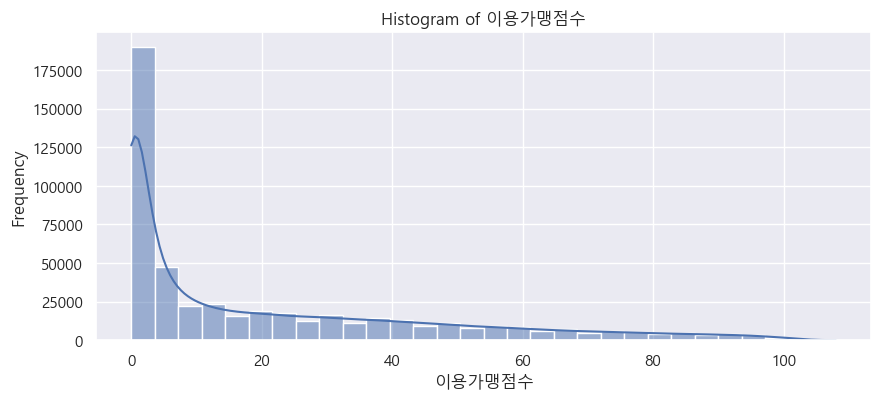


[📦 Boxplot for '이용가맹점수']



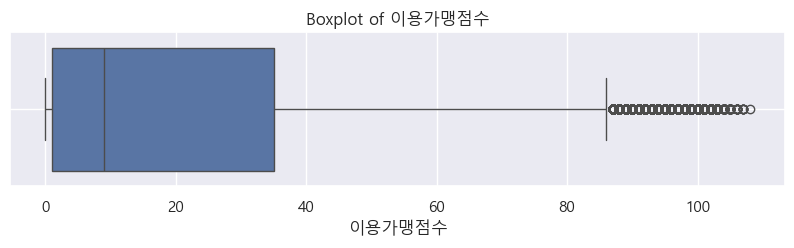

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '이용금액_해외']

이용금액_해외
0       447342
1331        95
1263        93
1323        93
1378        93
         ...  
2870         1
3725         1
4112         1
4138         1
3454         1
Name: count, Length: 3071, dtype: int64

[📈 Histogram for '이용금액_해외']



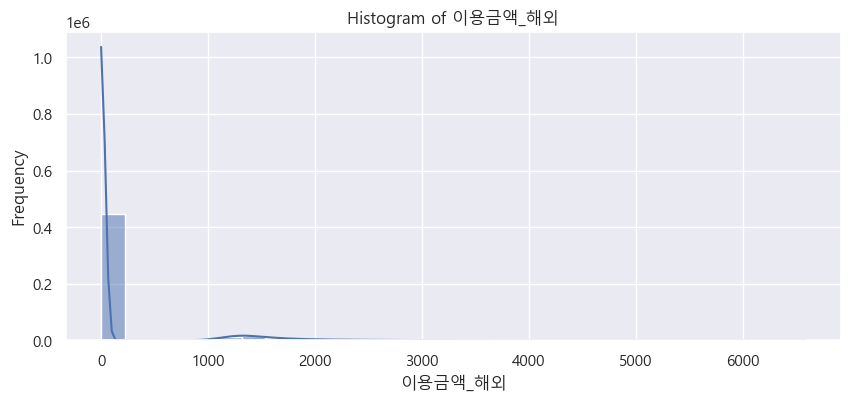


[📦 Boxplot for '이용금액_해외']



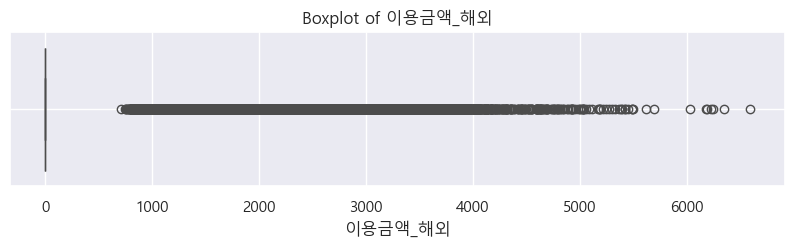

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '쇼핑_도소매_이용금액']

쇼핑_도소매_이용금액
0       275044
747        289
836        289
773        288
728        285
         ...  
5981         1
5483         1
3905         1
7590         1
4132         1
Name: count, Length: 5252, dtype: int64

[📈 Histogram for '쇼핑_도소매_이용금액']



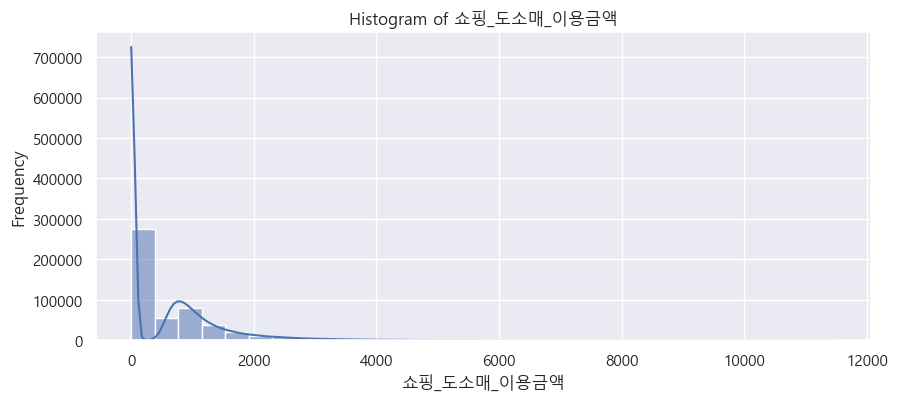


[📦 Boxplot for '쇼핑_도소매_이용금액']



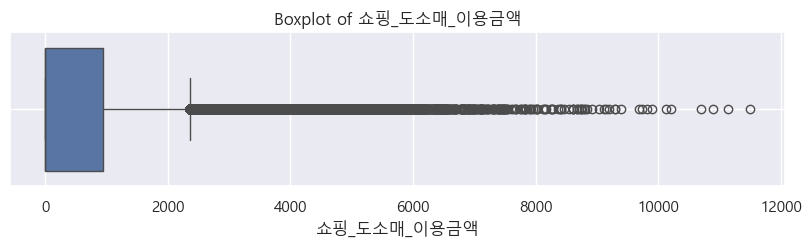

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '쇼핑_백화점_이용금액']

쇼핑_백화점_이용금액
0       418907
691        338
690        335
678        323
722        322
         ...  
1359         1
1682         1
1491         1
1349         1
1493         1
Name: count, Length: 1110, dtype: int64

[📈 Histogram for '쇼핑_백화점_이용금액']



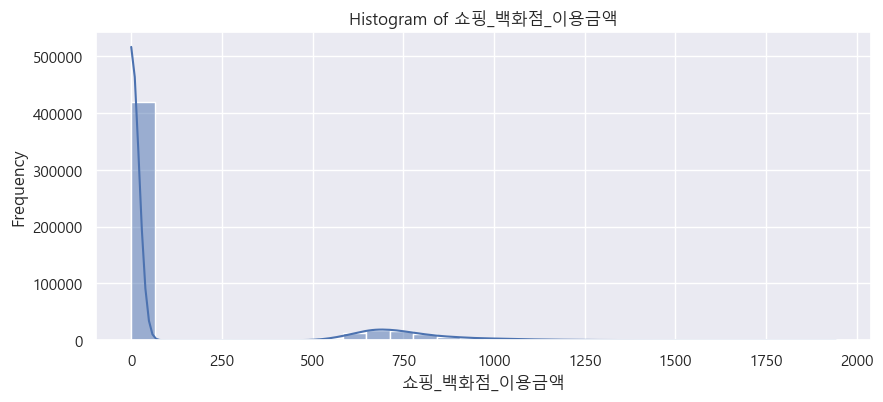


[📦 Boxplot for '쇼핑_백화점_이용금액']



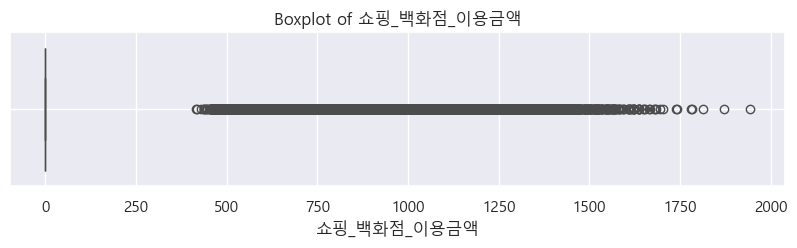

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '쇼핑_마트_이용금액']

쇼핑_마트_이용금액
0       337122
916        301
873        300
865        296
883        294
         ...  
2729         1
3503         1
4590         1
3104         1
3087         1
Name: count, Length: 3179, dtype: int64

[📈 Histogram for '쇼핑_마트_이용금액']



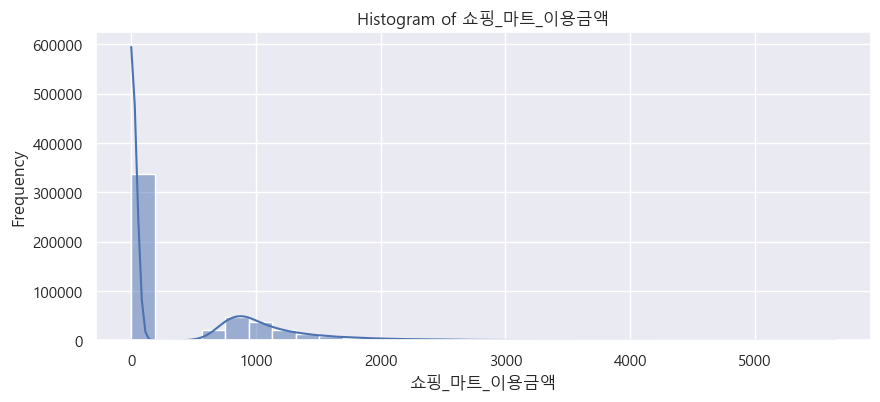


[📦 Boxplot for '쇼핑_마트_이용금액']



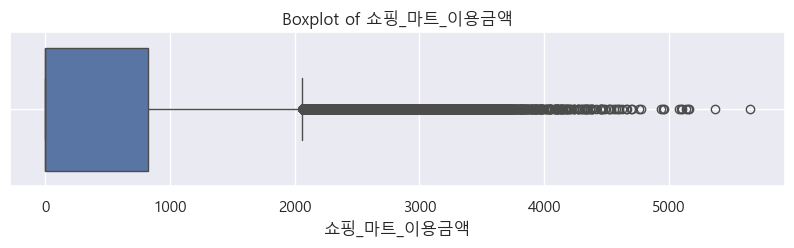

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '쇼핑_슈퍼마켓_이용금액']

쇼핑_슈퍼마켓_이용금액
0       274397
465        377
467        370
419        369
451        369
         ...  
2939         1
4311         1
2630         1
3056         1
3338         1
Name: count, Length: 3239, dtype: int64

[📈 Histogram for '쇼핑_슈퍼마켓_이용금액']



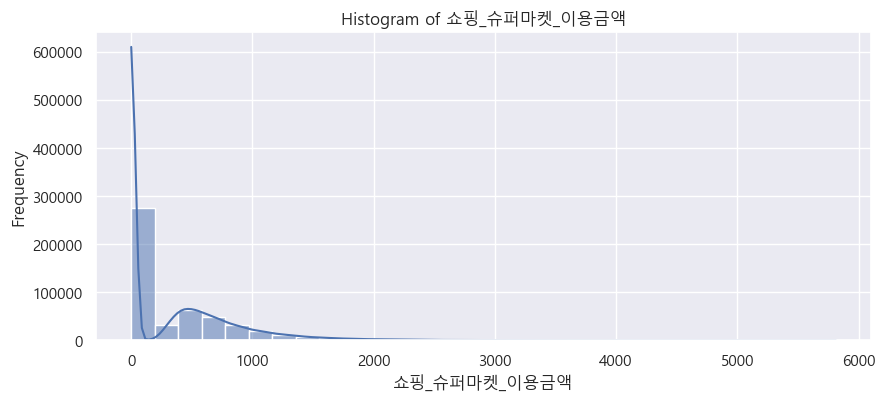


[📦 Boxplot for '쇼핑_슈퍼마켓_이용금액']



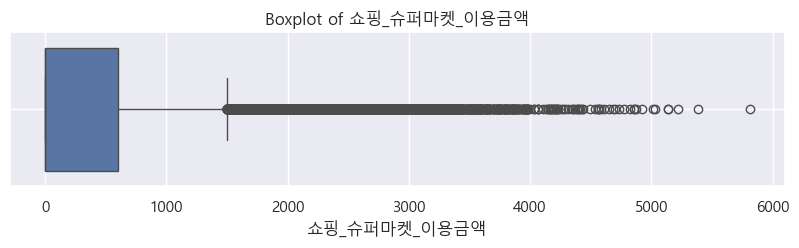

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '쇼핑_편의점_이용금액']

쇼핑_편의점_이용금액
0       297697
227        707
221        694
206        691
202        690
         ...  
3883         1
4243         1
2397         1
3390         1
3800         1
Name: count, Length: 3402, dtype: int64

[📈 Histogram for '쇼핑_편의점_이용금액']



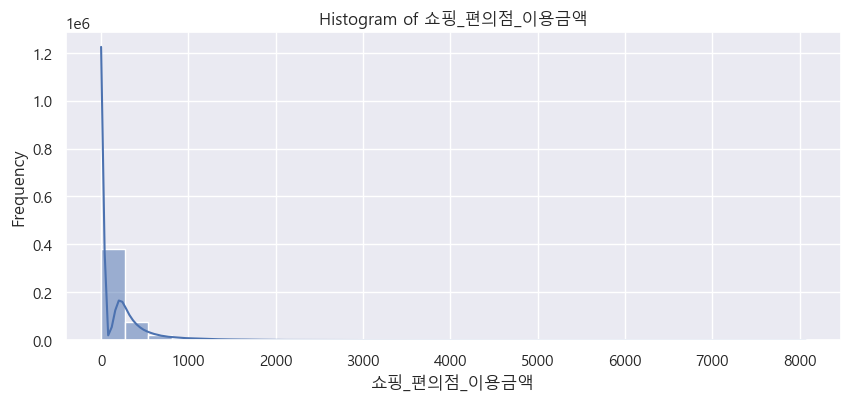


[📦 Boxplot for '쇼핑_편의점_이용금액']



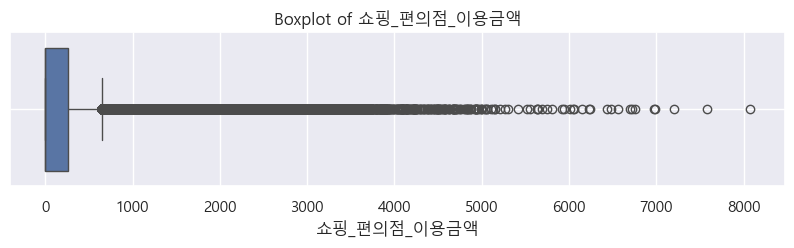

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '쇼핑_아울렛_이용금액']

쇼핑_아울렛_이용금액
0      441824
508       412
513       411
504       401
512       399
        ...  
883         1
805         1
870         1
841         1
827         1
Name: count, Length: 519, dtype: int64

[📈 Histogram for '쇼핑_아울렛_이용금액']



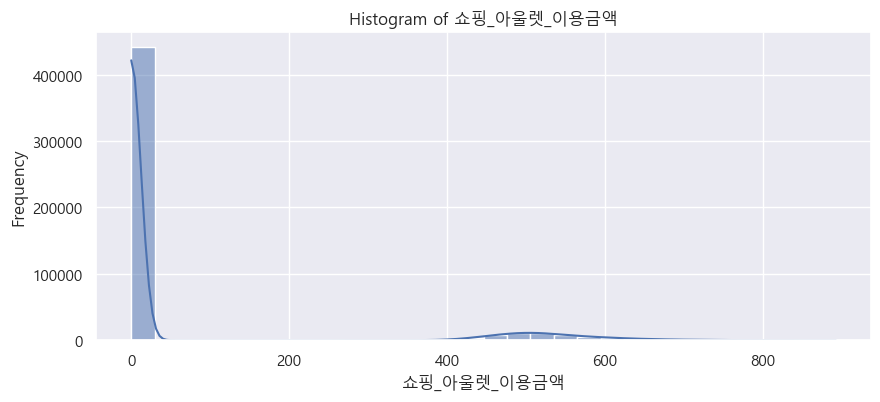


[📦 Boxplot for '쇼핑_아울렛_이용금액']



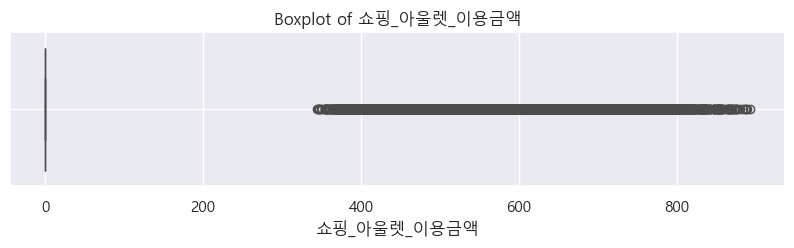

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '쇼핑_온라인_이용금액']

쇼핑_온라인_이용금액
0        307263
396         129
416         122
428         121
318         119
          ...  
15414         1
22408         1
36607         1
15048         1
35413         1
Name: count, Length: 22663, dtype: int64

[📈 Histogram for '쇼핑_온라인_이용금액']



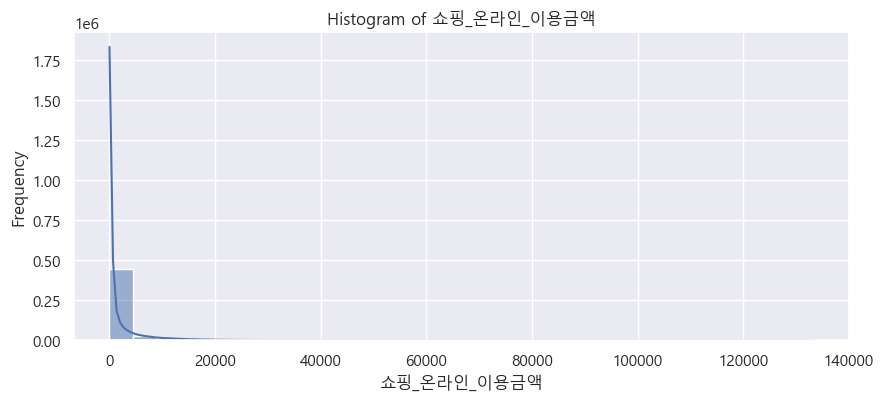


[📦 Boxplot for '쇼핑_온라인_이용금액']



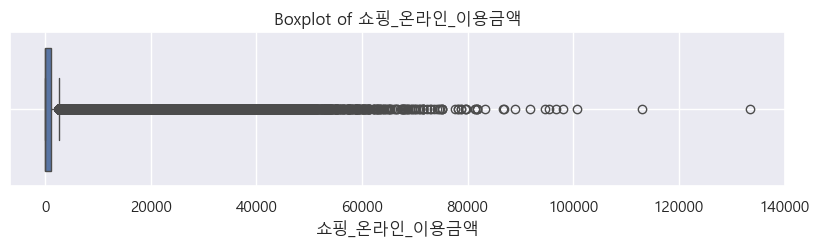

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '쇼핑_기타_이용금액']

쇼핑_기타_이용금액
0      359957
274       818
291       765
269       763
280       760
        ...  
766         1
804         1
879         1
858         1
785         1
Name: count, Length: 698, dtype: int64

[📈 Histogram for '쇼핑_기타_이용금액']



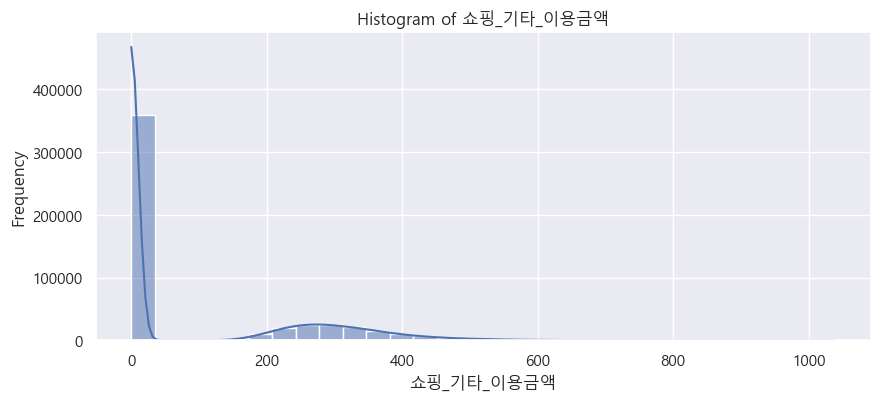


[📦 Boxplot for '쇼핑_기타_이용금액']



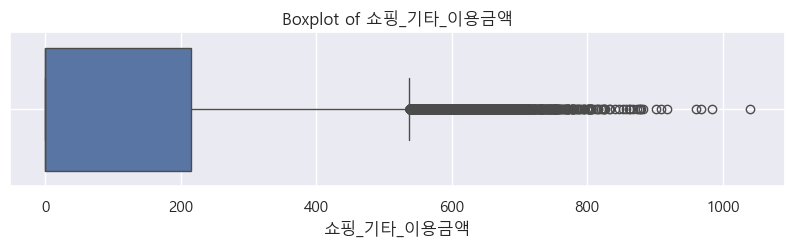

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '교통_주유이용금액']

교통_주유이용금액
0       350310
1690       158
1563       157
1507       155
1573       154
         ...  
6350         1
899          1
5098         1
7772         1
7220         1
Name: count, Length: 5587, dtype: int64

[📈 Histogram for '교통_주유이용금액']



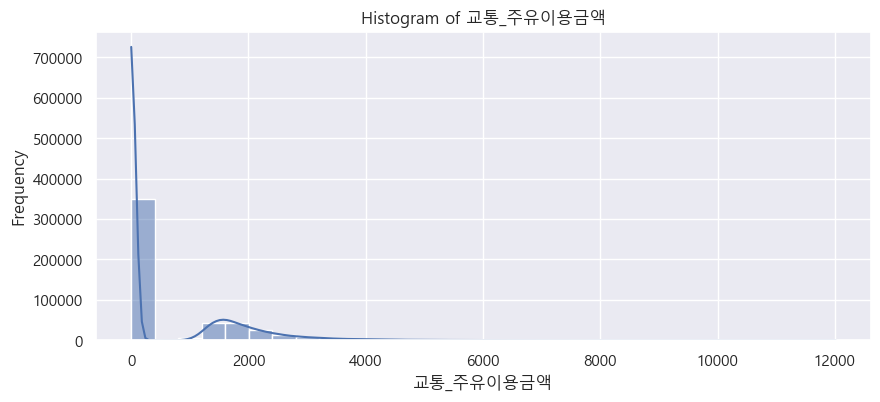


[📦 Boxplot for '교통_주유이용금액']



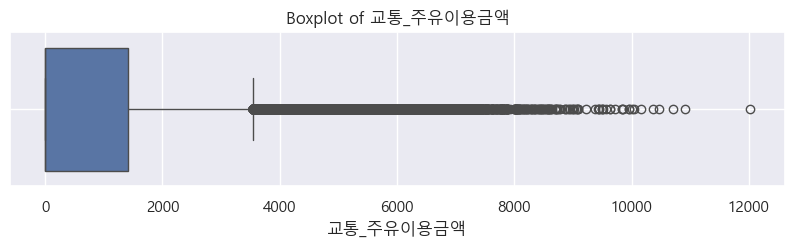

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '교통_정비이용금액']

교통_정비이용금액
0       387408
358        439
377        438
410        435
376        431
         ...  
1111         1
1276         1
1190         1
1268         1
1076         1
Name: count, Length: 1035, dtype: int64

[📈 Histogram for '교통_정비이용금액']



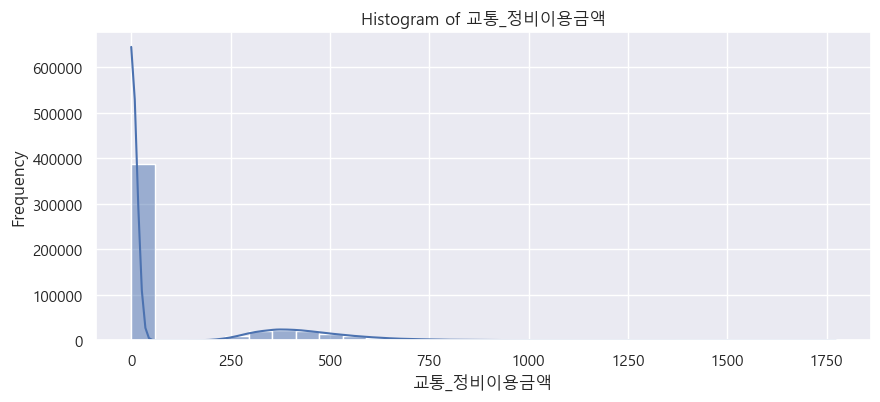


[📦 Boxplot for '교통_정비이용금액']



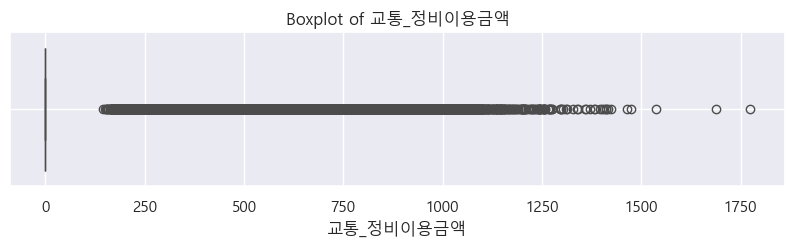

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '교통_통행료이용금액']

교통_통행료이용금액
0      499985
286         3
289         2
283         2
288         2
284         1
294         1
280         1
296         1
274         1
282         1
Name: count, dtype: int64

[📈 Histogram for '교통_통행료이용금액']



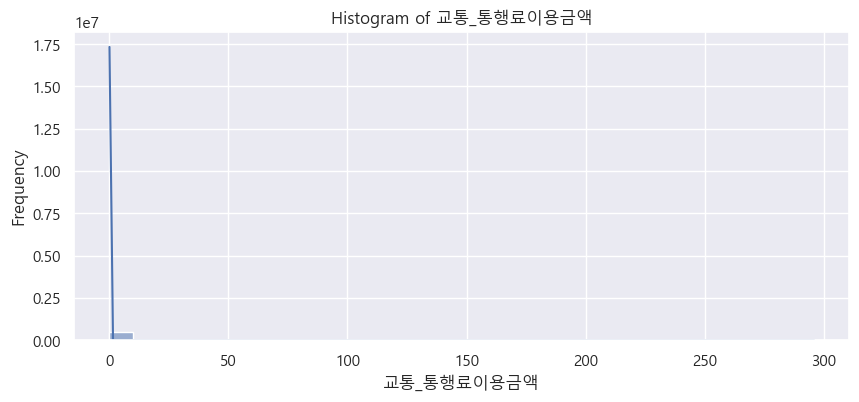


[📦 Boxplot for '교통_통행료이용금액']



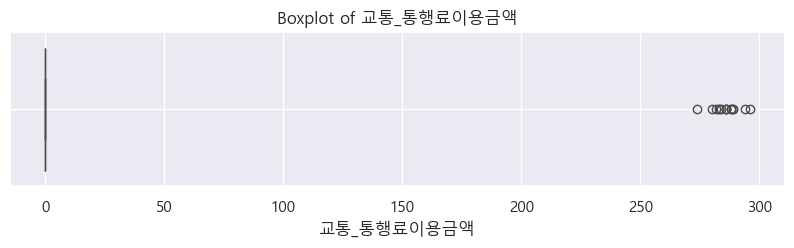

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '교통_버스지하철이용금액']

교통_버스지하철이용금액
0       382212
134        176
190        174
187        170
170        167
         ...  
2052         1
1998         1
2009         1
1878         1
2076         1
Name: count, Length: 2015, dtype: int64

[📈 Histogram for '교통_버스지하철이용금액']



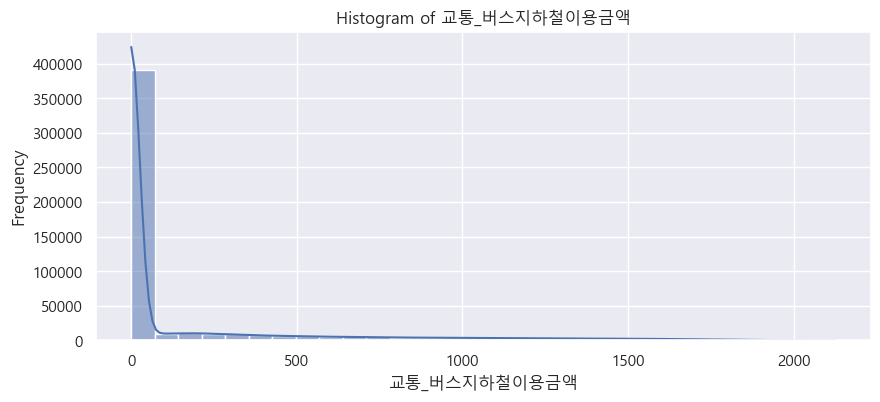


[📦 Boxplot for '교통_버스지하철이용금액']



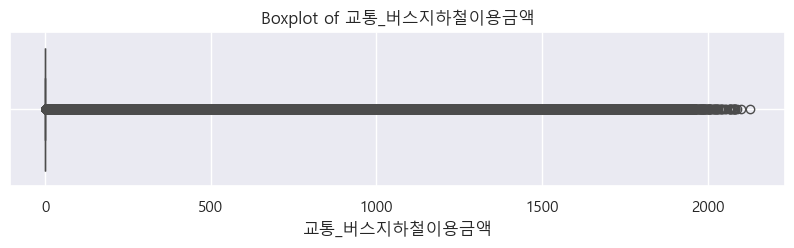

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '교통_택시이용금액']

교통_택시이용금액
0      392237
222       957
230       957
221       953
223       948
        ...  
812         1
692         1
135         1
675         1
734         1
Name: count, Length: 598, dtype: int64

[📈 Histogram for '교통_택시이용금액']



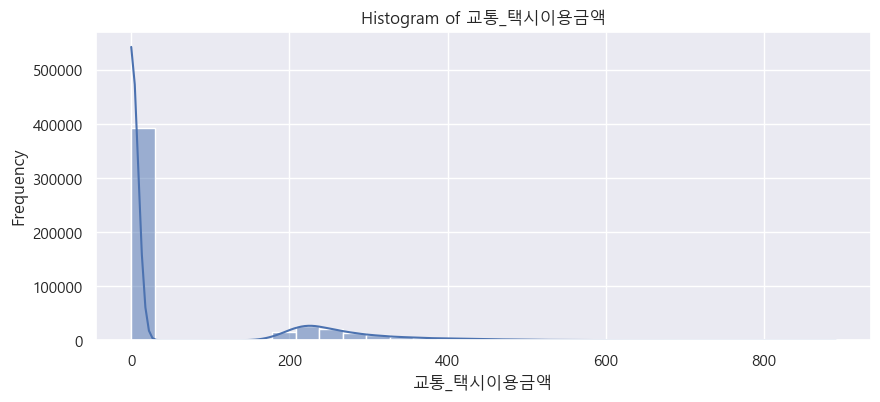


[📦 Boxplot for '교통_택시이용금액']



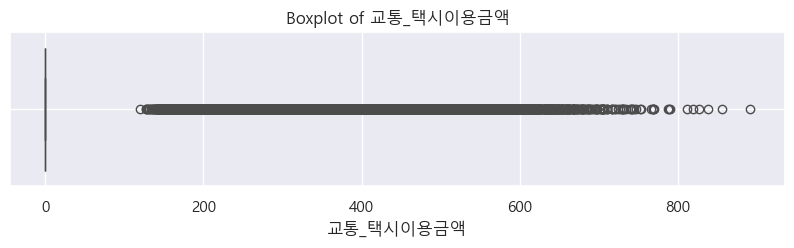

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '교통_철도버스이용금액']

교통_철도버스이용금액
0      438340
451       617
458       603
454       596
460       592
456       591
441       588
452       585
459       582
457       578
445       574
438       571
450       567
462       566
466       564
444       559
453       559
447       558
449       553
446       549
443       547
461       547
471       547
467       547
442       5

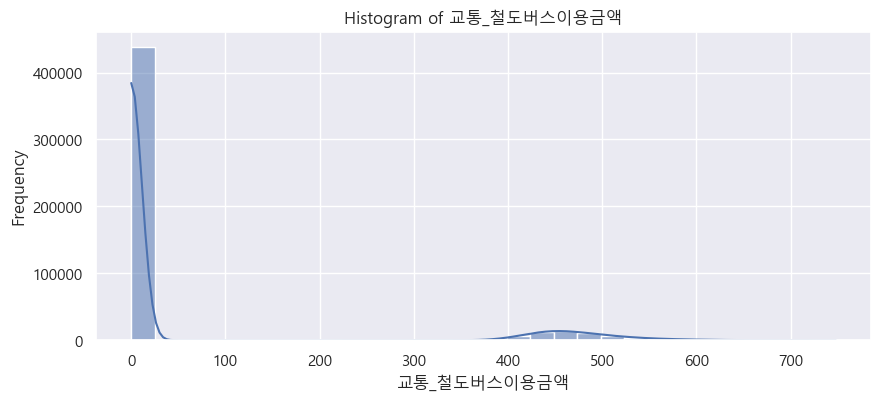


[📦 Boxplot for '교통_철도버스이용금액']



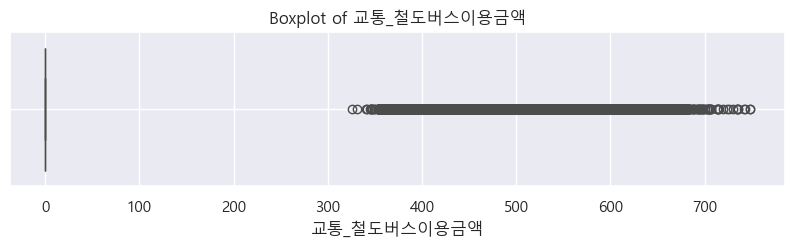

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '여유_운동이용금액']

여유_운동이용금액
0       426783
878        218
867        209
912        209
933        208
         ...  
1920         1
1722         1
2186         1
518          1
2280         1
Name: count, Length: 1575, dtype: int64

[📈 Histogram for '여유_운동이용금액']



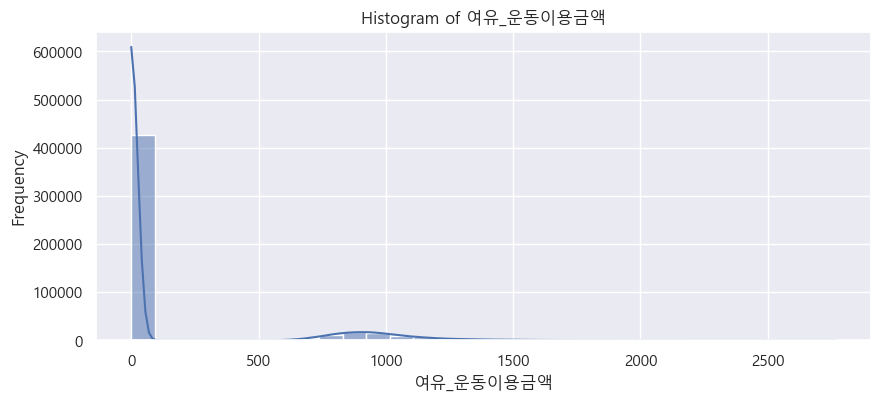


[📦 Boxplot for '여유_운동이용금액']



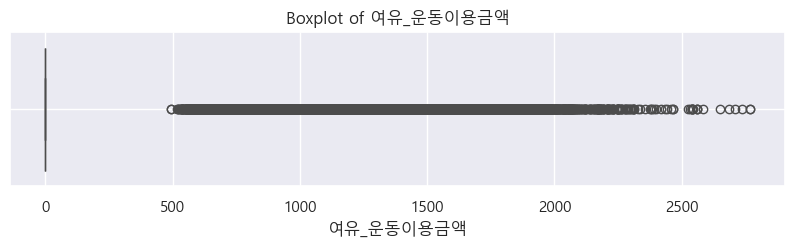

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '여유_Pet이용금액']

여유_Pet이용금액
0      482815
480       343
486       333
484       331
493       324
489       319
481       317
482       314
483       312
494       310
490       308
491       305
488       304
495       303
485       301
492       298
498       297
487       293
497       292
479       291
496       282
478       279
474       278
500       272
477       271

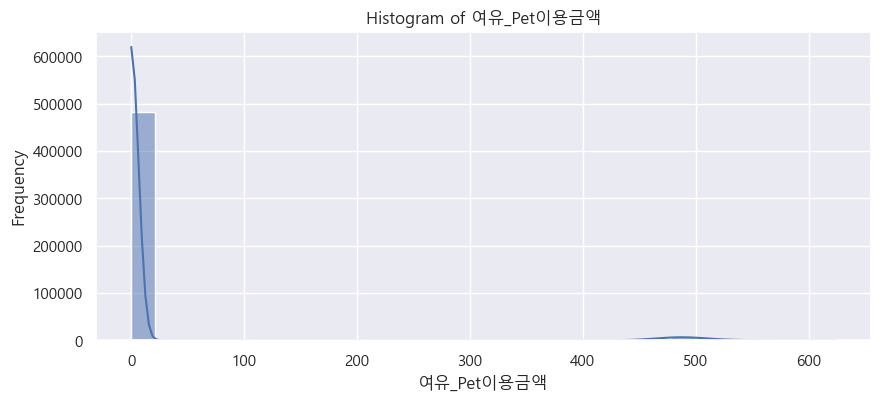


[📦 Boxplot for '여유_Pet이용금액']



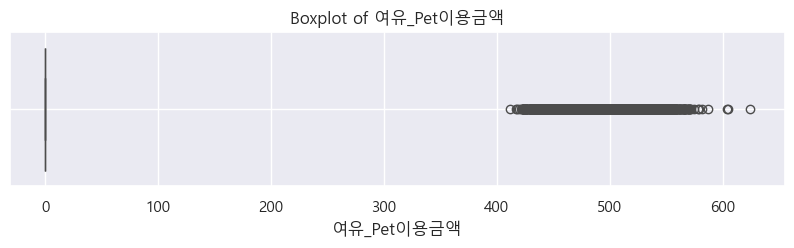

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '여유_공연이용금액']

여유_공연이용금액
0      456572
208      1673
207      1673
206      1607
205      1605
204      1594
209      1584
210      1578
211      1491
203      1462
212      1440
202      1434
213      1428
201      1357
214      1324
215      1293
200      1251
216      1129
199      1117
217      1055
198      1012
218       940
197       911
219       899
220       814
1

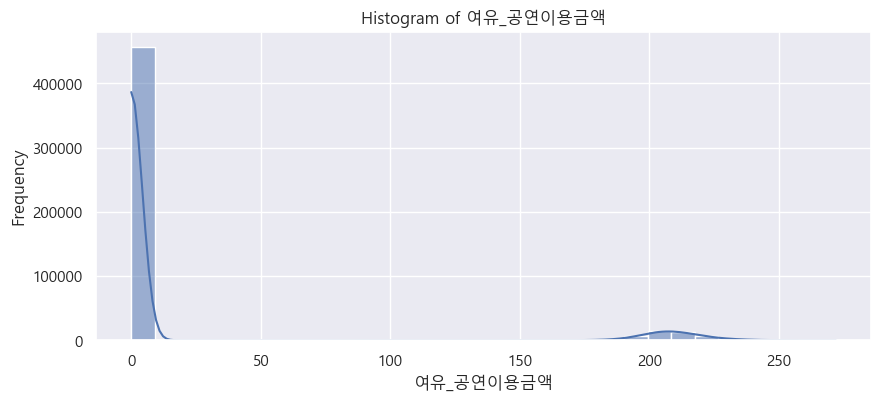


[📦 Boxplot for '여유_공연이용금액']



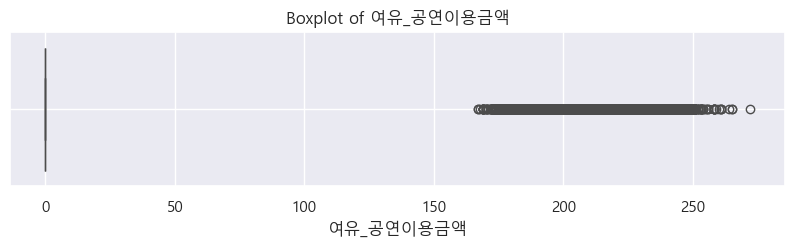

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '여유_공원이용금액']

여유_공원이용금액
0      497999
220       123
224       123
223       117
225       115
218       106
219       100
222        96
216        93
221        91
217        91
226        89
227        79
229        79
215        75
228        71
231        61
214        61
230        58
213        48
232        44
233        42
234        37
212        29
235        23
2

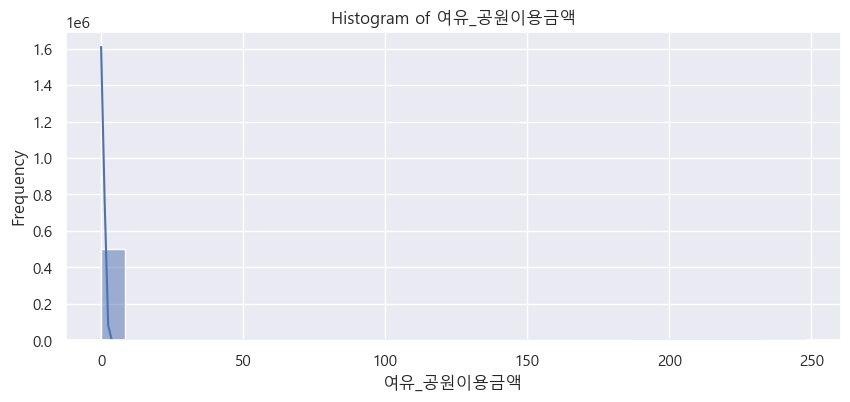


[📦 Boxplot for '여유_공원이용금액']



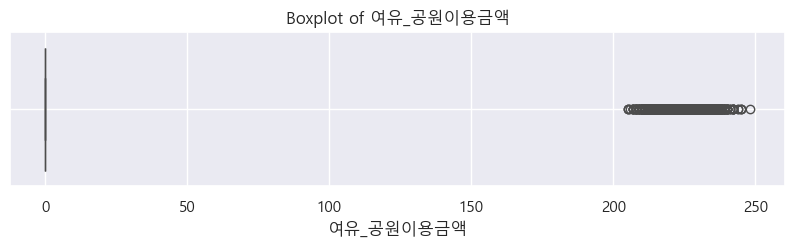

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '여유_숙박이용금액']

여유_숙박이용금액
0      492338
606        65
636        65
620        61
640        61
607        58
618        58
634        57
643        57
616        57
633        56
625        56
647        56
619        54
627        54
623        54
608        53
637        53
611        53
628        52
661        52
622        52
629        52
612        52
610        51
6

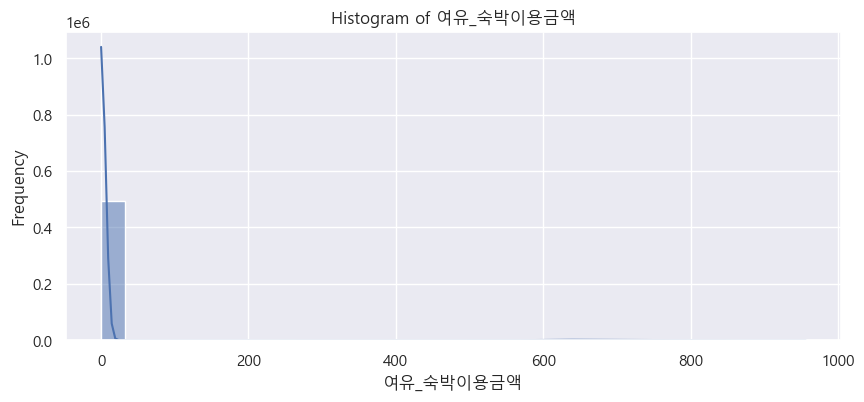


[📦 Boxplot for '여유_숙박이용금액']



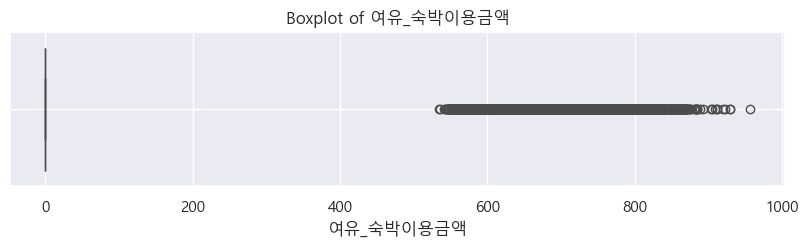

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '여유_여행이용금액']

여유_여행이용금액
0    500000
Name: count, dtype: int64

[📈 Histogram for '여유_여행이용금액']



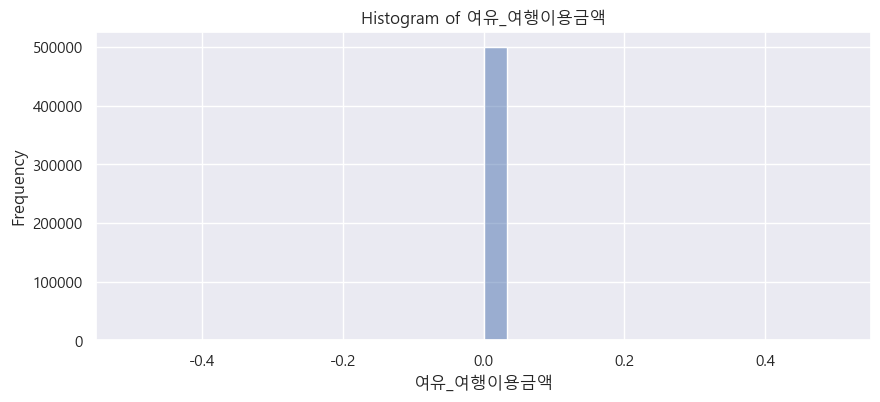


[📦 Boxplot for '여유_여행이용금액']



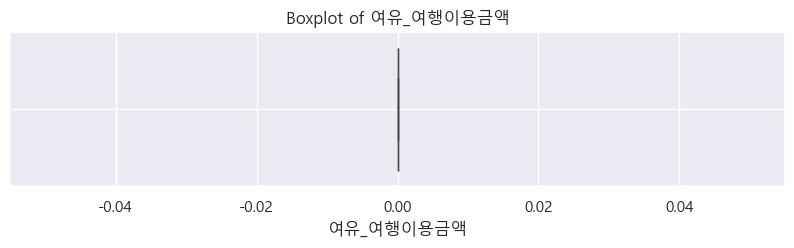

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '여유_항공이용금액']

여유_항공이용금액
0       496984
2882        12
2715        12
3107        12
2819        11
         ...  
2733         1
3218         1
3373         1
2575         1
3472         1
Name: count, Length: 849, dtype: int64

[📈 Histogram for '여유_항공이용금액']



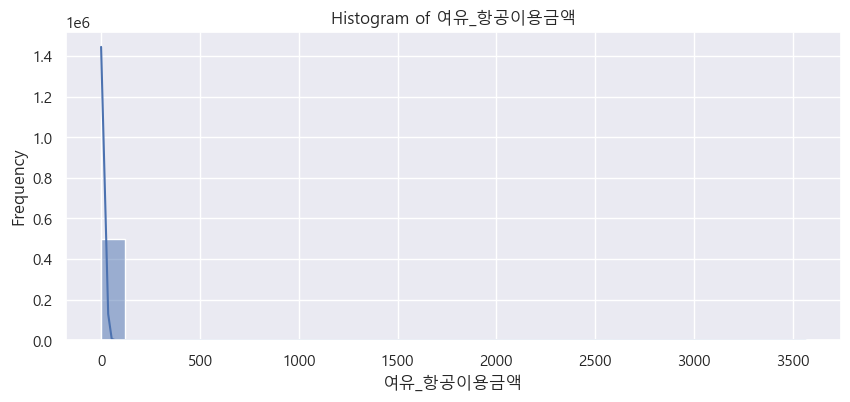


[📦 Boxplot for '여유_항공이용금액']



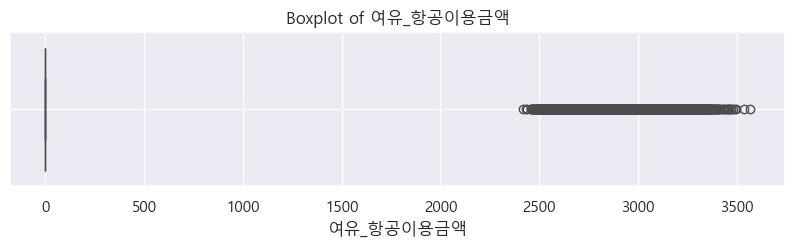

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '여유_기타이용금액']

여유_기타이용금액
0      463104
214       896
219       860
218       841
217       835
223       819
222       818
216       814
220       812
221       804
210       796
213       785
212       780
215       776
224       764
225       748
209       747
227       740
211       738
208       728
228       727
226       718
230       678
229       671
205       669
2

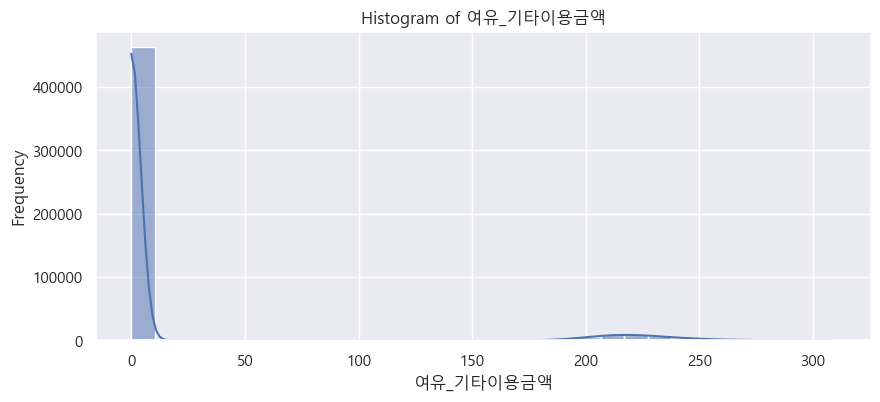


[📦 Boxplot for '여유_기타이용금액']



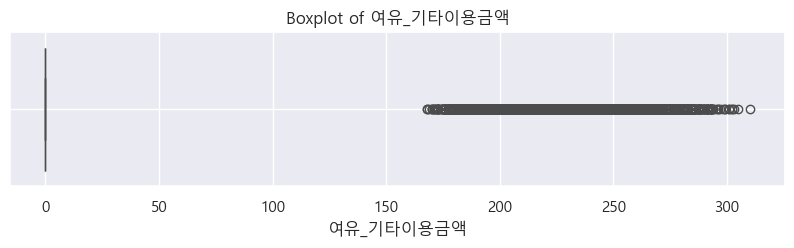

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '납부_통신비이용금액']

납부_통신비이용금액
0       349428
1316       130
1488       126
1359       124
1369       123
         ...  
5114         1
6156         1
5148         1
6221         1
5244         1
Name: count, Length: 5067, dtype: int64

[📈 Histogram for '납부_통신비이용금액']



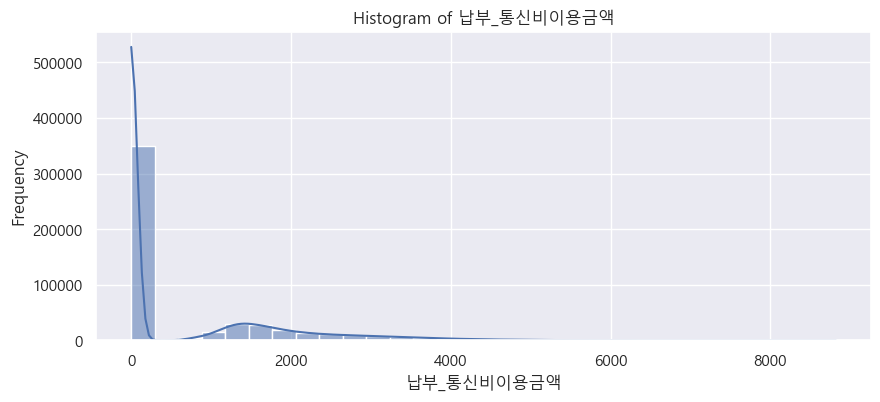


[📦 Boxplot for '납부_통신비이용금액']



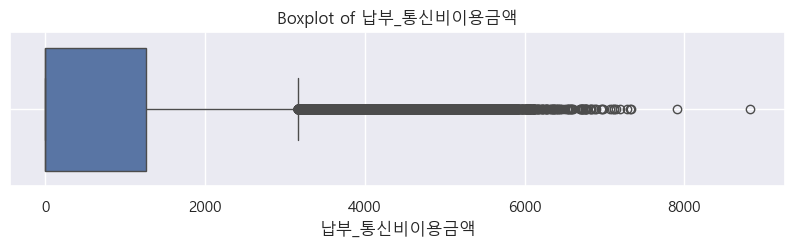

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '납부_관리비이용금액']

납부_관리비이용금액
0       484990
4722        79
4718        76
4683        75
4687        74
         ...  
4412         1
4393         1
4973         1
4449         1
4945         1
Name: count, Length: 589, dtype: int64

[📈 Histogram for '납부_관리비이용금액']



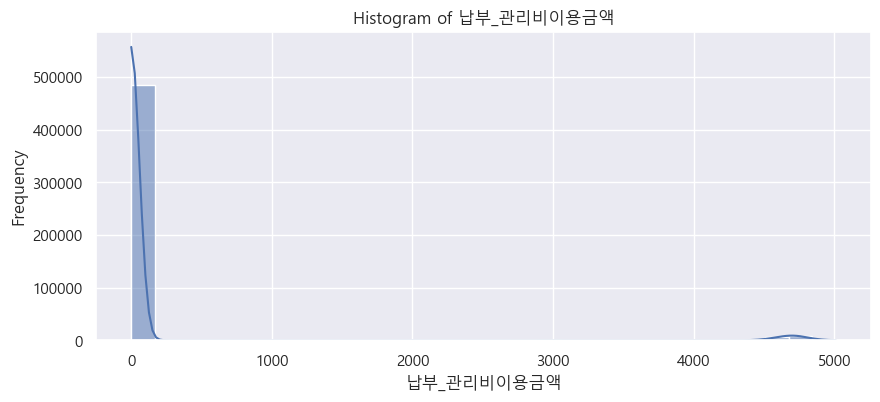


[📦 Boxplot for '납부_관리비이용금액']



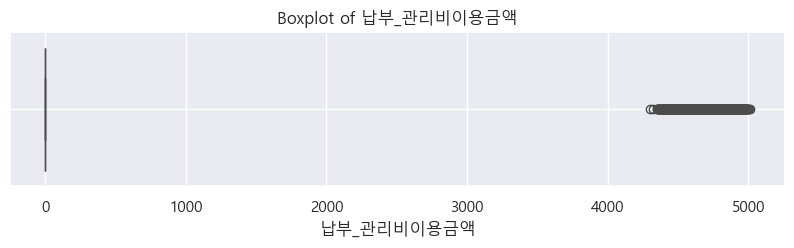

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '납부_렌탈료이용금액']

납부_렌탈료이용금액
0    500000
Name: count, dtype: int64

[📈 Histogram for '납부_렌탈료이용금액']



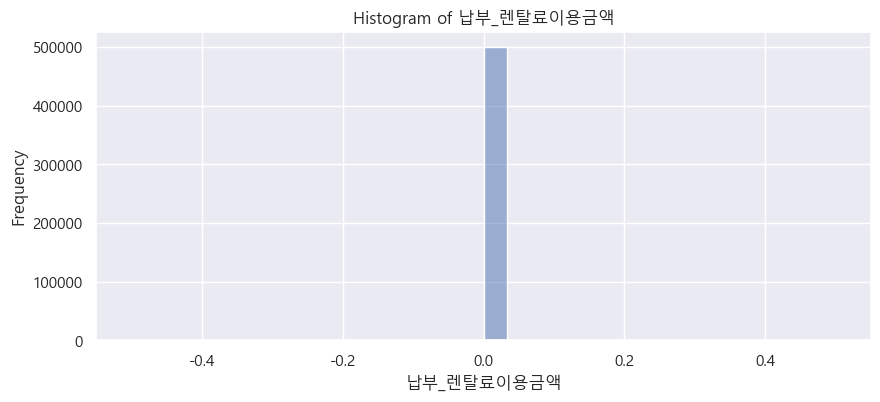


[📦 Boxplot for '납부_렌탈료이용금액']



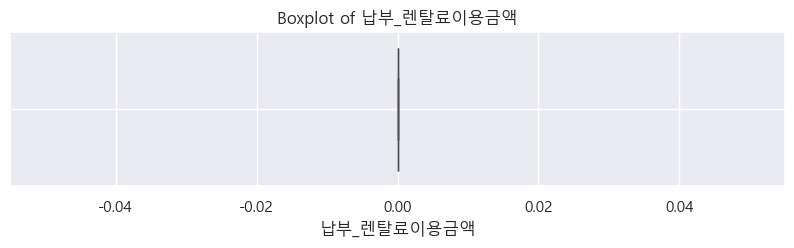

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '납부_가스전기료이용금액']

납부_가스전기료이용금액
0      490025
592       117
597       116
598       114
609       114
586       111
596       108
599       108
631       102
591       101
588       101
575       100
601       100
589        99
607        97
611        97
594        97
590        97
584        96
593        94
602        94
617        94
580        93
583        93
572      

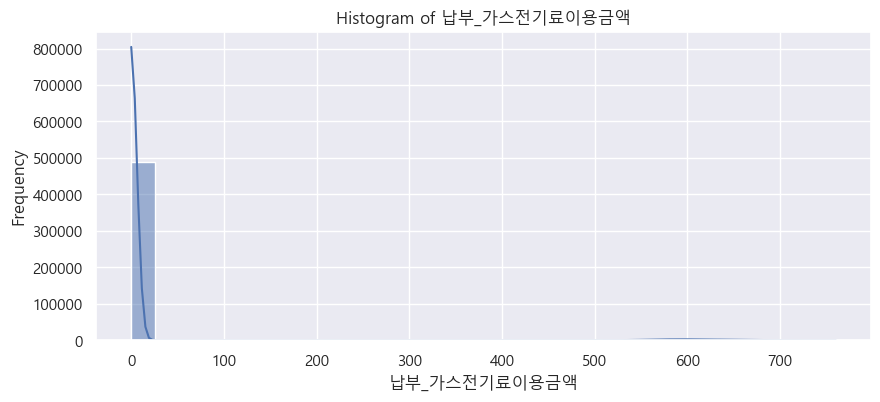


[📦 Boxplot for '납부_가스전기료이용금액']



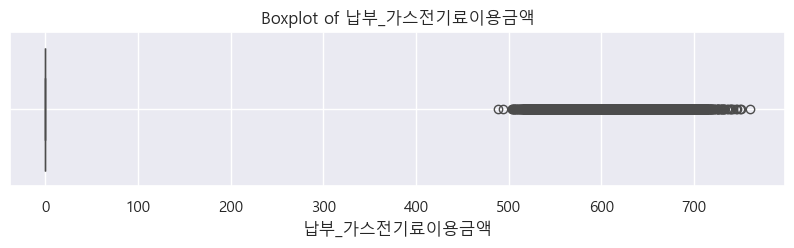

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '납부_보험료이용금액']

납부_보험료이용금액
0       446873
2089       110
2166       109
2039       106
2013       106
         ...  
2793         1
1501         1
3371         1
3070         1
3002         1
Name: count, Length: 1579, dtype: int64

[📈 Histogram for '납부_보험료이용금액']



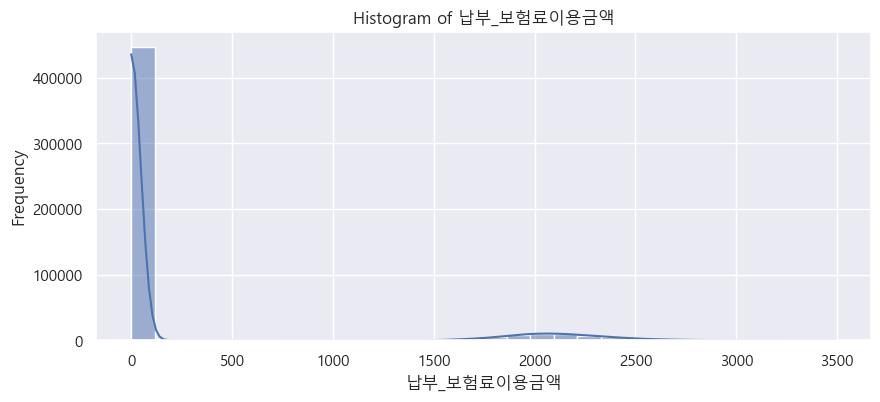


[📦 Boxplot for '납부_보험료이용금액']



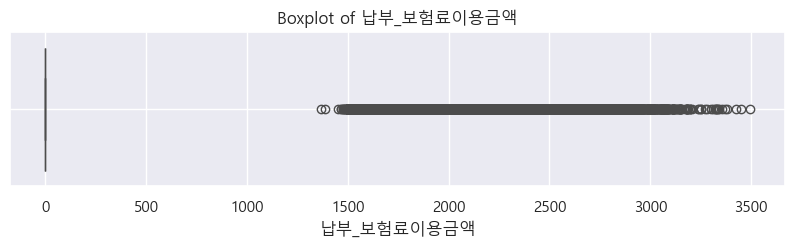

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '납부_유선방송이용금액']

납부_유선방송이용금액
0    500000
Name: count, dtype: int64

[📈 Histogram for '납부_유선방송이용금액']



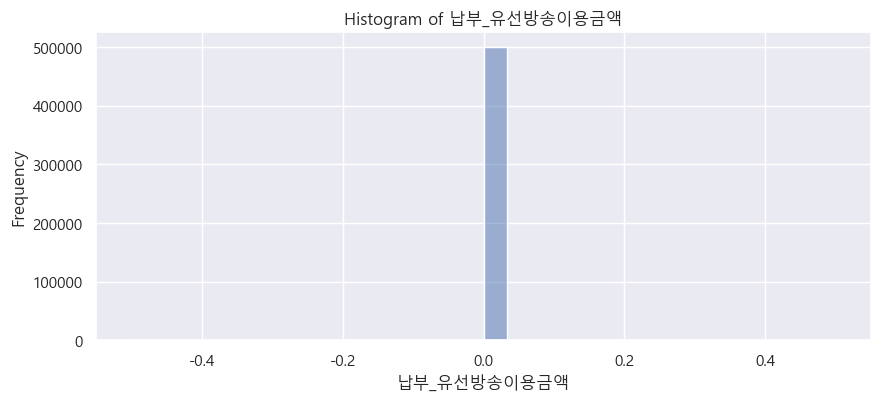


[📦 Boxplot for '납부_유선방송이용금액']



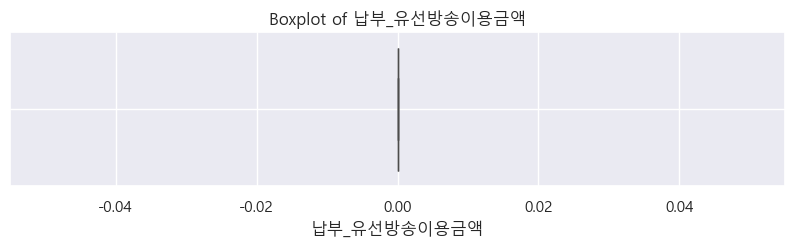

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '납부_건강연금이용금액']

납부_건강연금이용금액
0    500000
Name: count, dtype: int64

[📈 Histogram for '납부_건강연금이용금액']



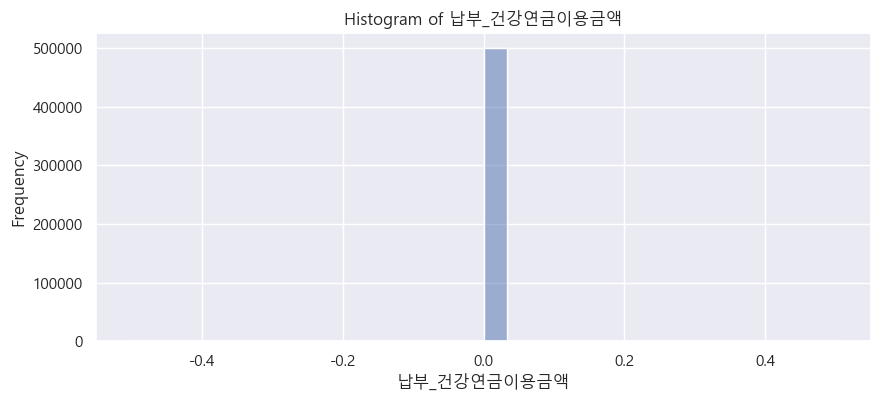


[📦 Boxplot for '납부_건강연금이용금액']



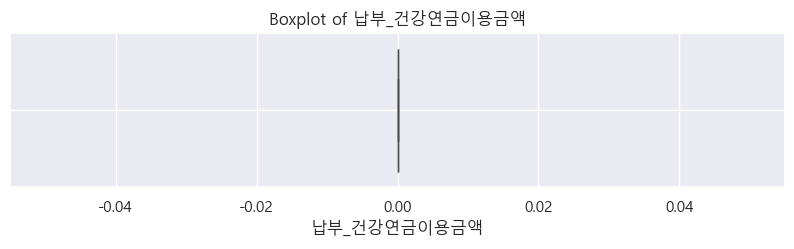

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '납부_기타이용금액']

납부_기타이용금액
0       373168
24        2111
23        2007
25        1952
22        1706
         ...  
914          1
886          1
891          1
853          1
1050         1
Name: count, Length: 930, dtype: int64

[📈 Histogram for '납부_기타이용금액']



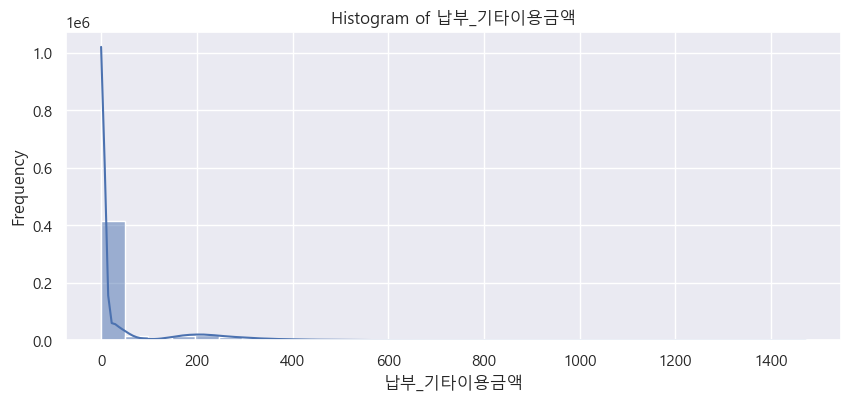


[📦 Boxplot for '납부_기타이용금액']



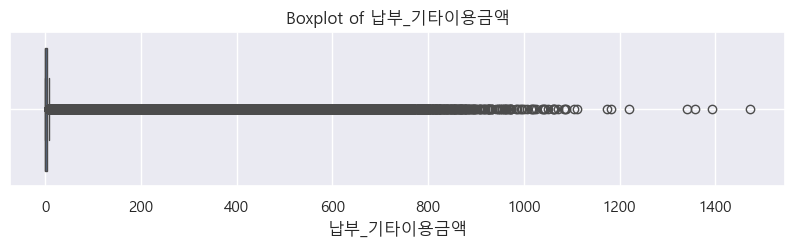

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_1순위업종']

_1순위업종
쇼핑      218239
None     99731
납부       83972
교통       39981
사교활동     26624
교육       16763
의료        6933
해외        6574
여유생활      1070
일상생활       112
요식           1
Name: count, dtype: int64

[📈 Histogram for '_1순위업종']



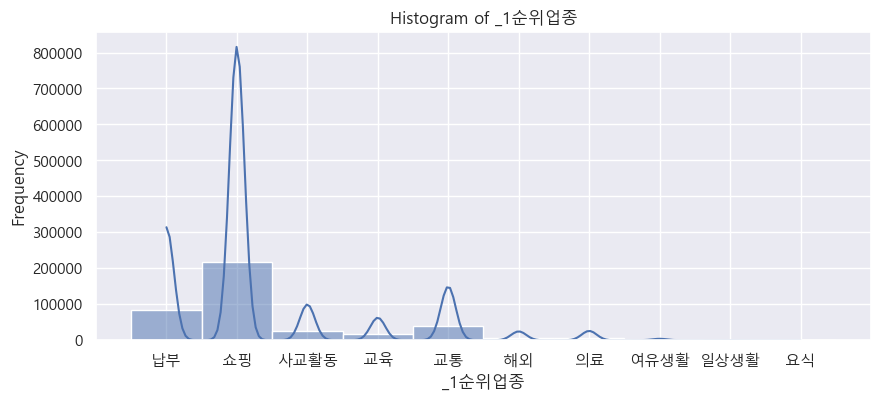


[📦 Boxplot for '_1순위업종']



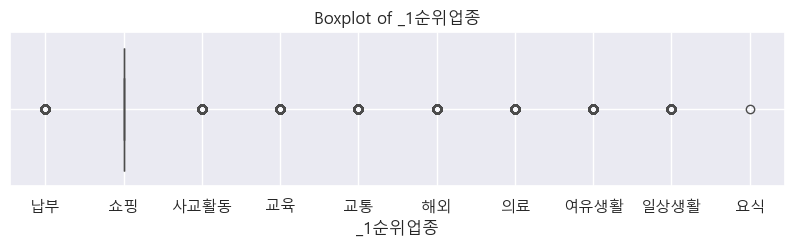

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_1순위업종_이용금액']

_1순위업종_이용금액
0        99736
24        1991
23        1899
25        1820
22        1621
         ...  
38507        1
46199        1
31373        1
39060        1
66818        1
Name: count, Length: 38934, dtype: int64

[📈 Histogram for '_1순위업종_이용금액']



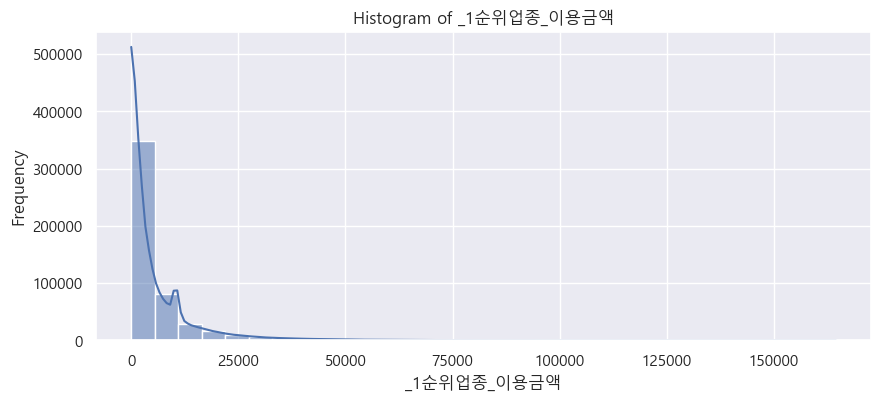


[📦 Boxplot for '_1순위업종_이용금액']



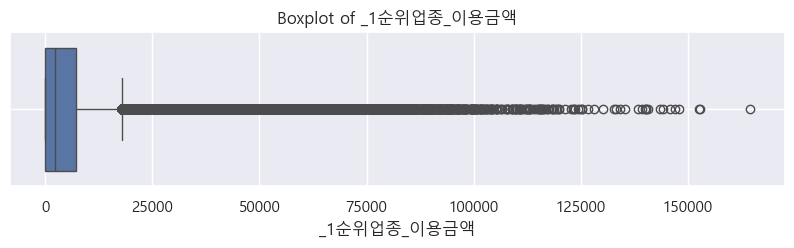

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_2순위업종']

_2순위업종
None    177724
사교활동    111467
쇼핑       69246
납부       55328
교통       49206
의료       17827
교육        8447
해외        6591
여유생활      3405
일상생활       733
요식          26
Name: count, dtype: int64

[📈 Histogram for '_2순위업종']



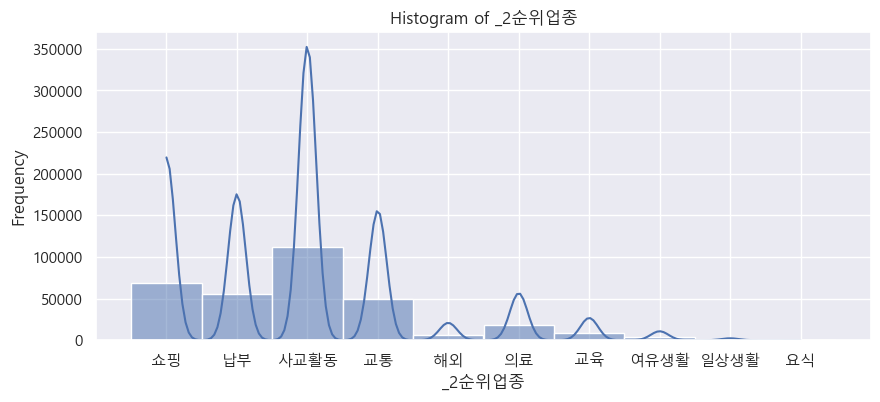


[📦 Boxplot for '_2순위업종']



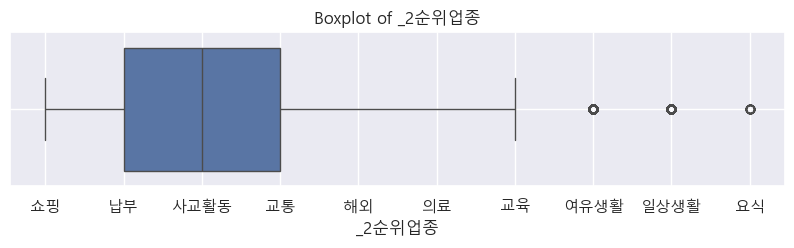

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_2순위업종_이용금액']

_2순위업종_이용금액
0        177729
35          192
1739        189
38          186
36          185
          ...  
12124         1
11215         1
16431         1
16742         1
16475         1
Name: count, Length: 16786, dtype: int64

[📈 Histogram for '_2순위업종_이용금액']



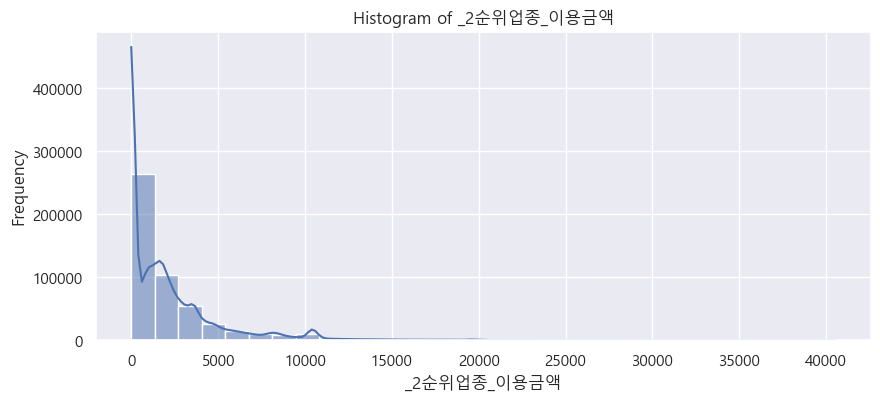


[📦 Boxplot for '_2순위업종_이용금액']



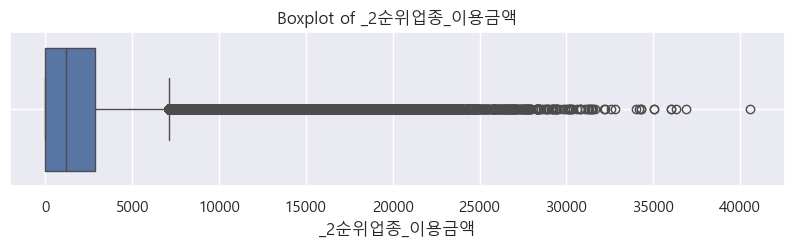

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_3순위업종']

_3순위업종
None    219474
사교활동     87299
교통       80707
납부       35903
쇼핑       26890
의료       24303
여유생활      9199
해외        7483
일상생활      3723
요식        2786
교육        2233
Name: count, dtype: int64

[📈 Histogram for '_3순위업종']



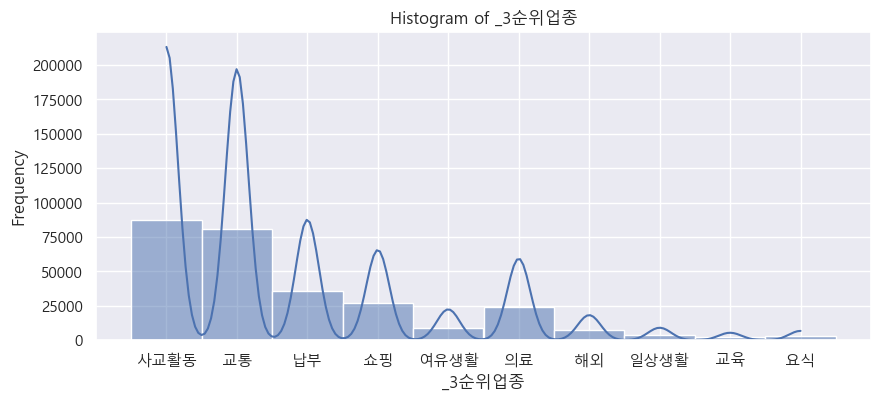


[📦 Boxplot for '_3순위업종']



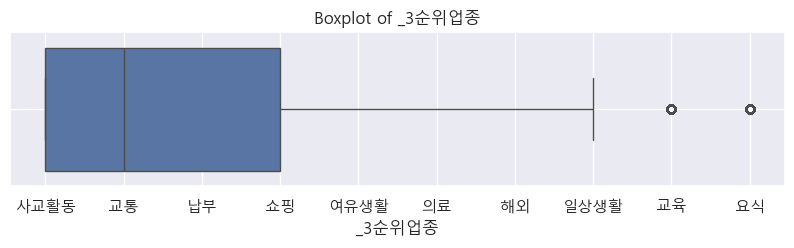

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_3순위업종_이용금액']

_3순위업종_이용금액
0        219478
903         309
900         300
897         295
904         284
          ...  
18358         1
9022          1
9748          1
9662          1
13769         1
Name: count, Length: 10521, dtype: int64

[📈 Histogram for '_3순위업종_이용금액']



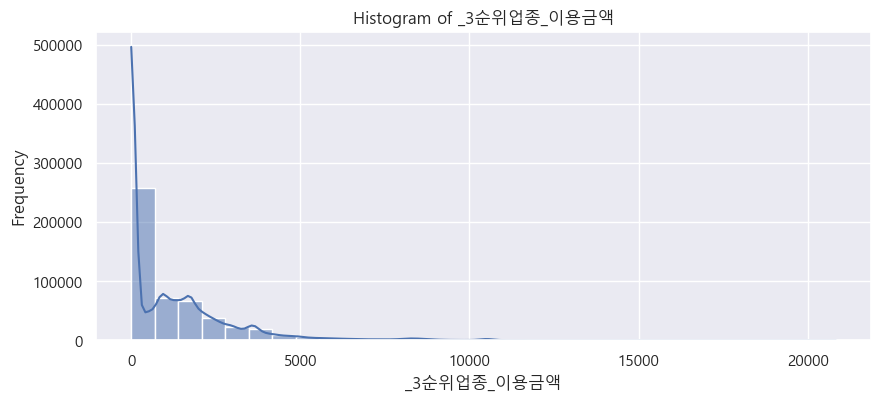


[📦 Boxplot for '_3순위업종_이용금액']



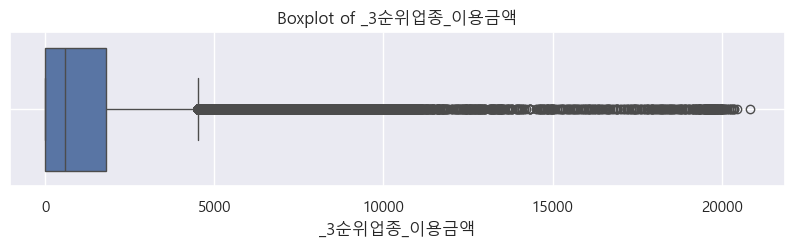

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_1순위쇼핑업종']

_1순위쇼핑업종
None    179908
온라인     135550
도소매      95034
마트       47614
슈퍼마켓     21341
편의점      12085
백화점       4736
쇼핑기타      2549
아울렛       1183
Name: count, dtype: int64

[📈 Histogram for '_1순위쇼핑업종']



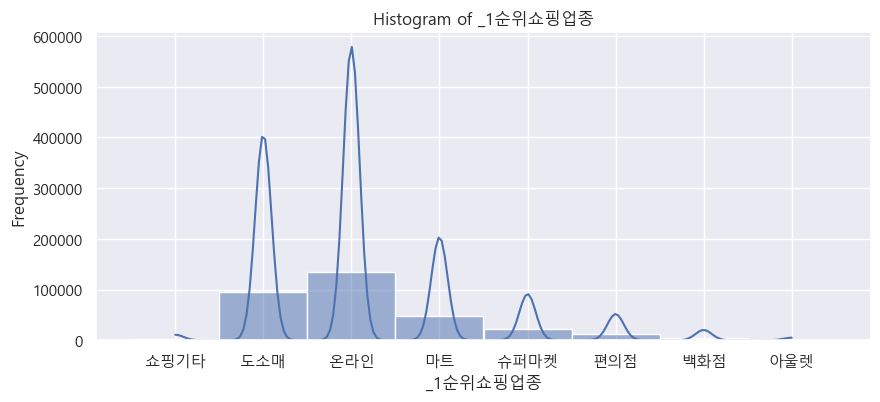


[📦 Boxplot for '_1순위쇼핑업종']



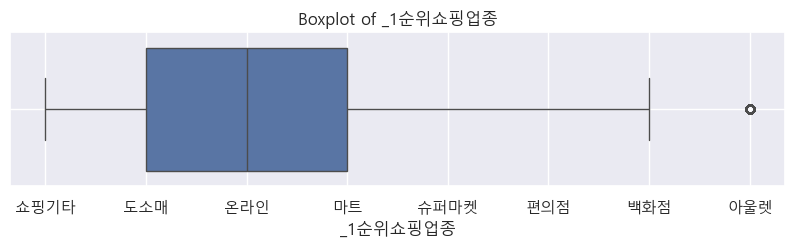

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_1순위쇼핑업종_이용금액']

_1순위쇼핑업종_이용금액
0        179908
864         301
825         291
794         285
917         281
          ...  
36607         1
15048         1
40690         1
9514          1
35413         1
Name: count, Length: 22658, dtype: int64

[📈 Histogram for '_1순위쇼핑업종_이용금액']



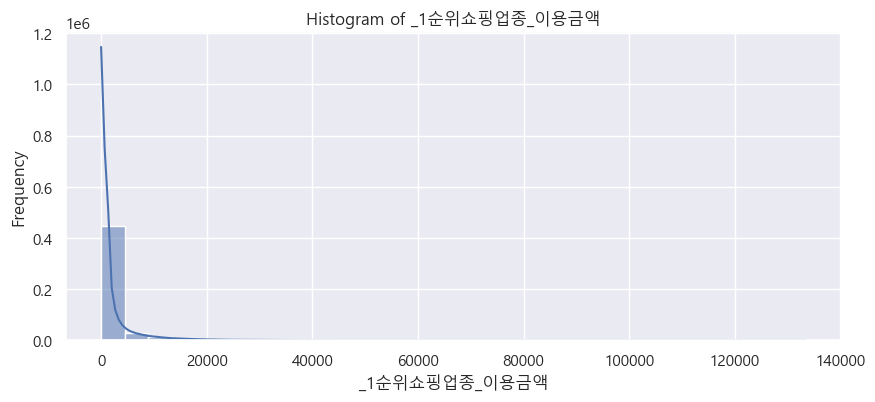


[📦 Boxplot for '_1순위쇼핑업종_이용금액']



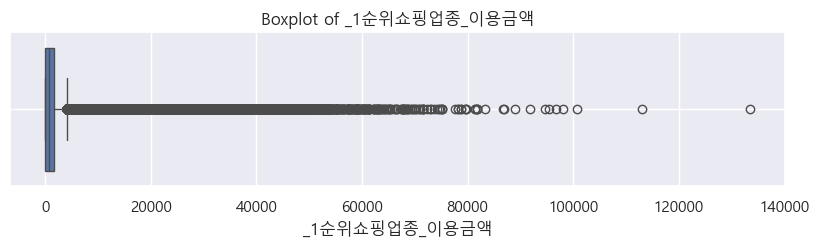

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_2순위쇼핑업종']

_2순위쇼핑업종
None    230490
도소매      79843
마트       69748
슈퍼마켓     56574
편의점      23877
온라인      17652
백화점      12454
쇼핑기타      6324
아울렛       3038
Name: count, dtype: int64

[📈 Histogram for '_2순위쇼핑업종']



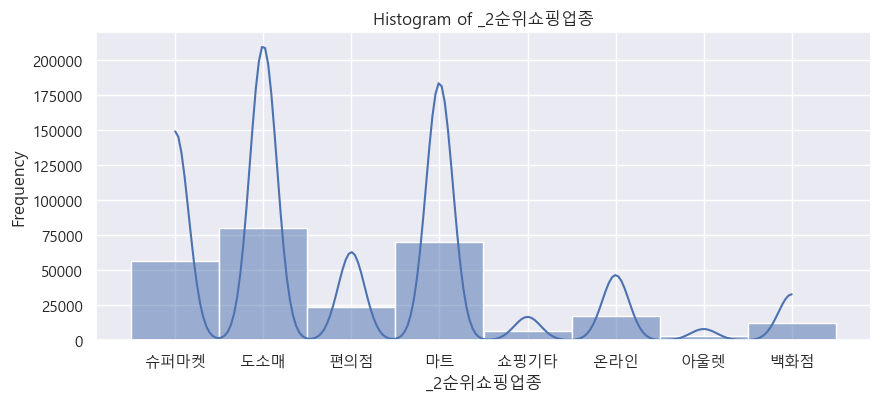


[📦 Boxplot for '_2순위쇼핑업종']



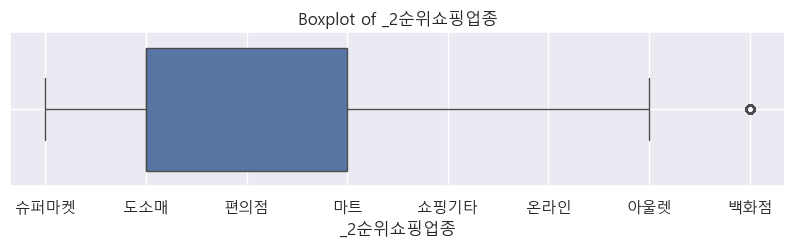

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_2순위쇼핑업종_이용금액']

_2순위쇼핑업종_이용금액
0       230490
699        331
696        330
764        328
735        326
         ...  
5010         1
84           1
3570         1
6118         1
3714         1
Name: count, Length: 4648, dtype: int64

[📈 Histogram for '_2순위쇼핑업종_이용금액']



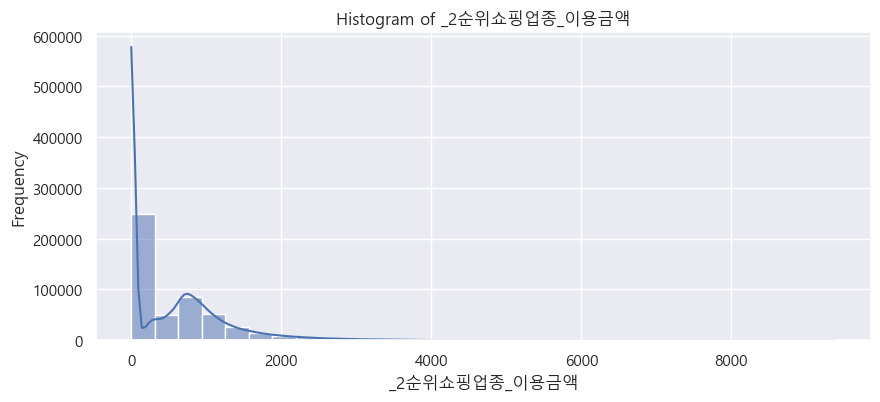


[📦 Boxplot for '_2순위쇼핑업종_이용금액']



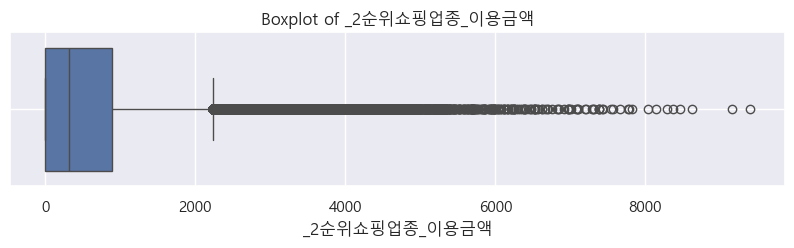

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_3순위쇼핑업종']

_3순위쇼핑업종
None    269661
슈퍼마켓     71348
도소매      37497
마트       35917
편의점      32900
백화점      19747
쇼핑기타     13344
온라인      12703
아울렛       6883
Name: count, dtype: int64

[📈 Histogram for '_3순위쇼핑업종']



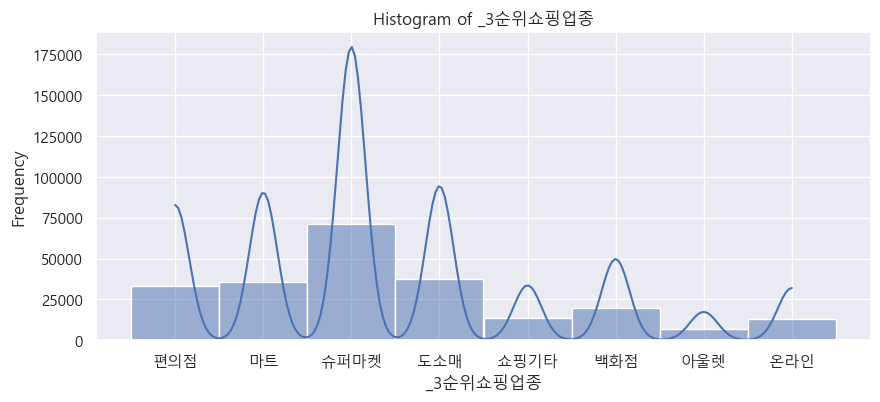


[📦 Boxplot for '_3순위쇼핑업종']



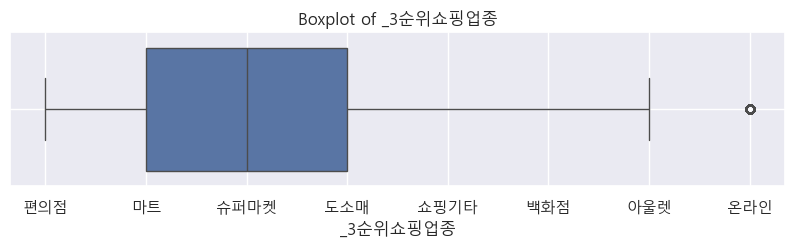

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_3순위쇼핑업종_이용금액']

_3순위쇼핑업종_이용금액
0       269661
681        312
697        309
656        308
673        305
         ...  
3432         1
2960         1
3594         1
4609         1
2673         1
Name: count, Length: 3320, dtype: int64

[📈 Histogram for '_3순위쇼핑업종_이용금액']



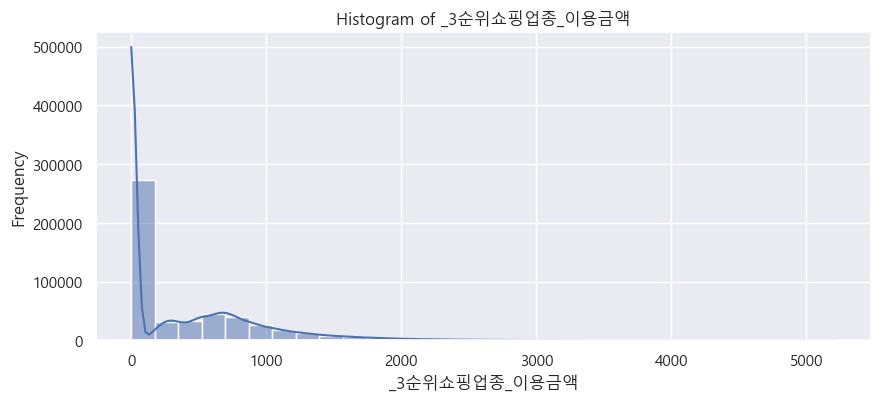


[📦 Boxplot for '_3순위쇼핑업종_이용금액']



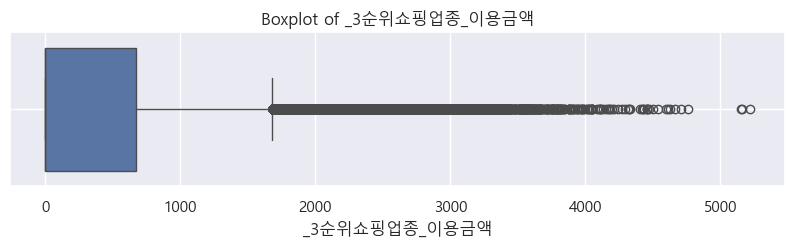

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_1순위교통업종']

_1순위교통업종
None     233003
주유       148187
버스지하철     57157
정비        26837
택시        17991
철도버스      16825
Name: count, dtype: int64

[📈 Histogram for '_1순위교통업종']



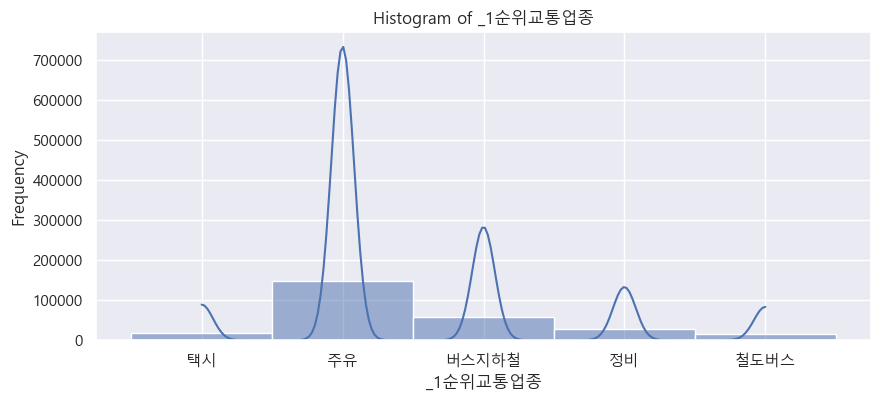


[📦 Boxplot for '_1순위교통업종']



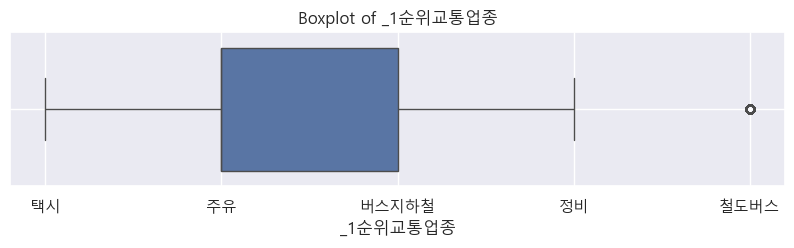

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_1순위교통업종_이용금액']

_1순위교통업종_이용금액
0       233028
454        375
451        370
460        349
445        345
         ...  
7709         1
6564         1
6295         1
4894         1
7220         1
Name: count, Length: 6431, dtype: int64

[📈 Histogram for '_1순위교통업종_이용금액']



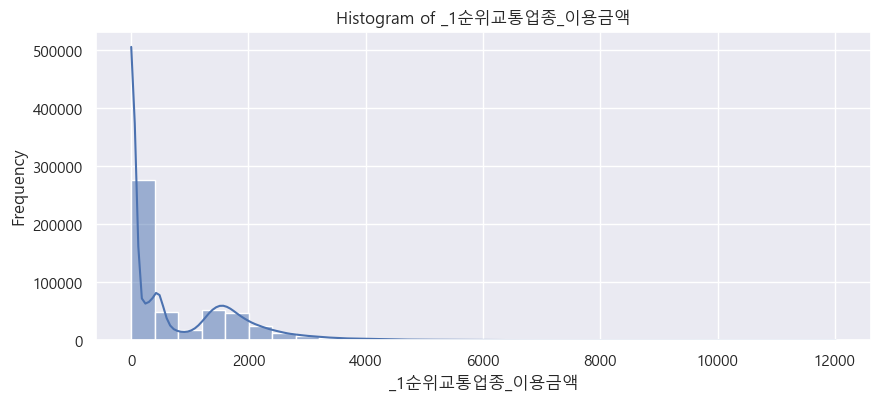


[📦 Boxplot for '_1순위교통업종_이용금액']



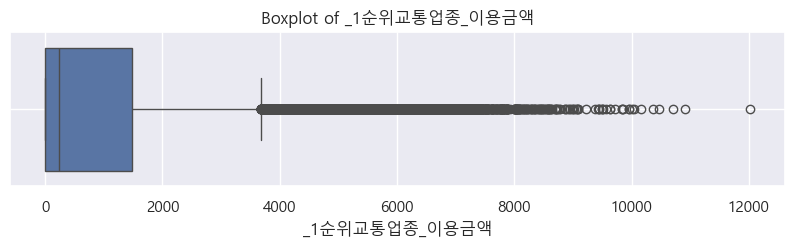

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_2순위교통업종']

_2순위교통업종
None     337085
정비        59328
버스지하철     37453
택시        34853
철도버스      29774
주유         1503
통행료           4
Name: count, dtype: int64

[📈 Histogram for '_2순위교통업종']



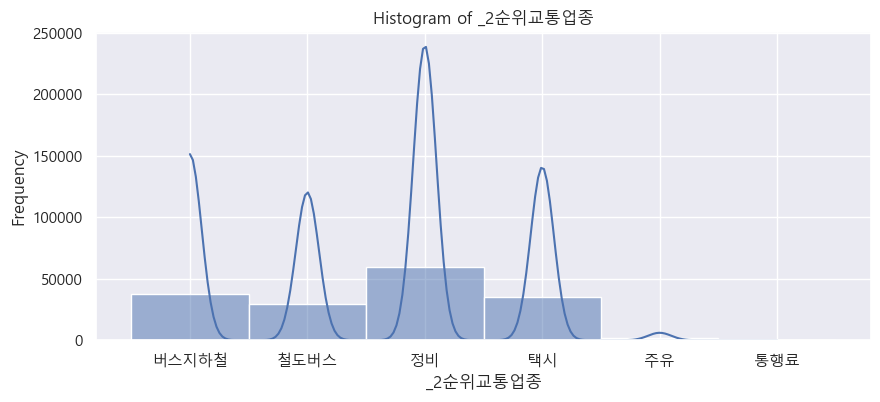


[📦 Boxplot for '_2순위교통업종']



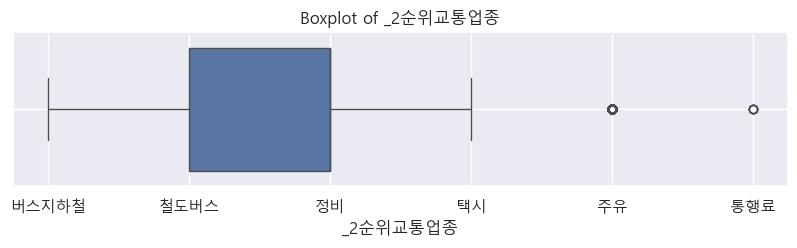

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_2순위교통업종_이용금액']

_2순위교통업종_이용금액
0       337117
441        562
438        542
450        540
452        523
         ...  
1904         1
1804         1
1776         1
1798         1
1808         1
Name: count, Length: 1829, dtype: int64

[📈 Histogram for '_2순위교통업종_이용금액']



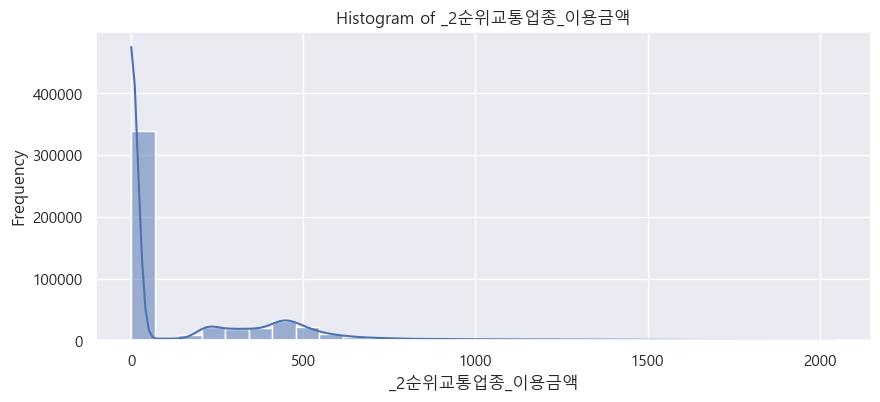


[📦 Boxplot for '_2순위교통업종_이용금액']



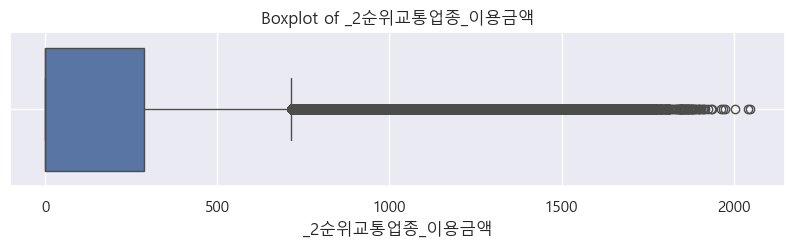

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_3순위교통업종']

_3순위교통업종
None     419699
택시        33185
정비        19637
버스지하철     14404
철도버스      13072
통행료           3
Name: count, dtype: int64

[📈 Histogram for '_3순위교통업종']



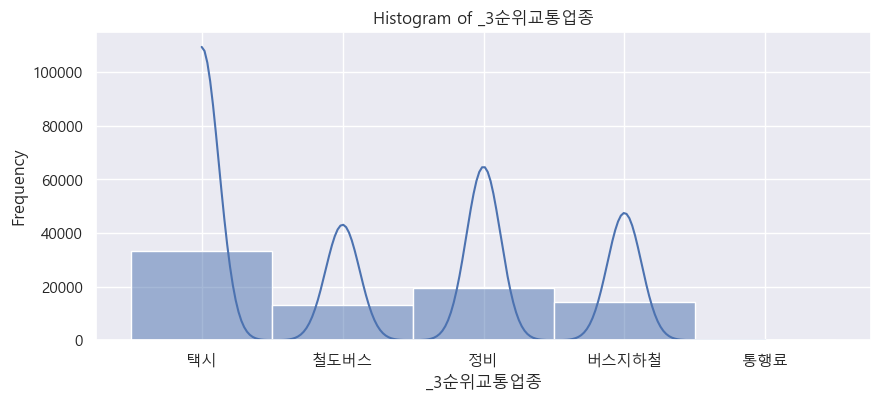


[📦 Boxplot for '_3순위교통업종']



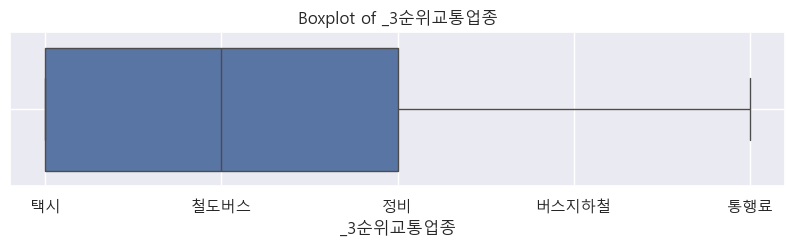

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_3순위교통업종_이용금액']

_3순위교통업종_이용금액
0      419721
230       324
234       315
247       313
215       311
        ...  
795         1
833         1
857         1
787         1
870         1
Name: count, Length: 877, dtype: int64

[📈 Histogram for '_3순위교통업종_이용금액']



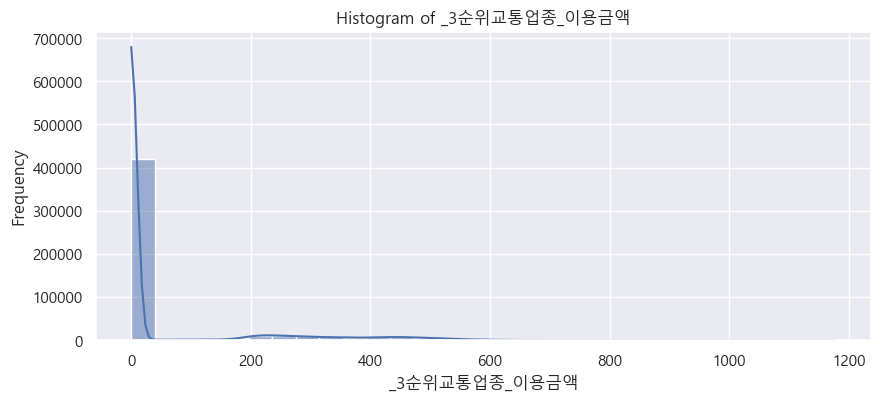


[📦 Boxplot for '_3순위교통업종_이용금액']



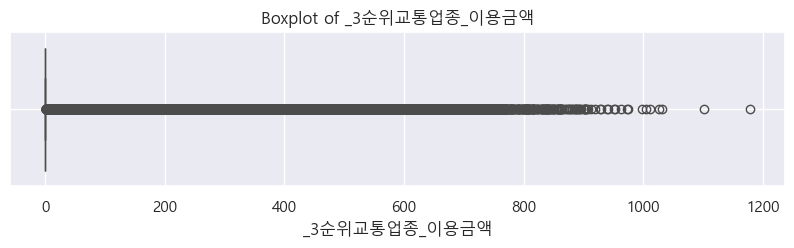

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_1순위여유업종']

_1순위여유업종
None    372556
운동       71919
공연       20391
여유기타     18212
Pet      10569
숙박        3038
항공        3016
공원         299
Name: count, dtype: int64

[📈 Histogram for '_1순위여유업종']



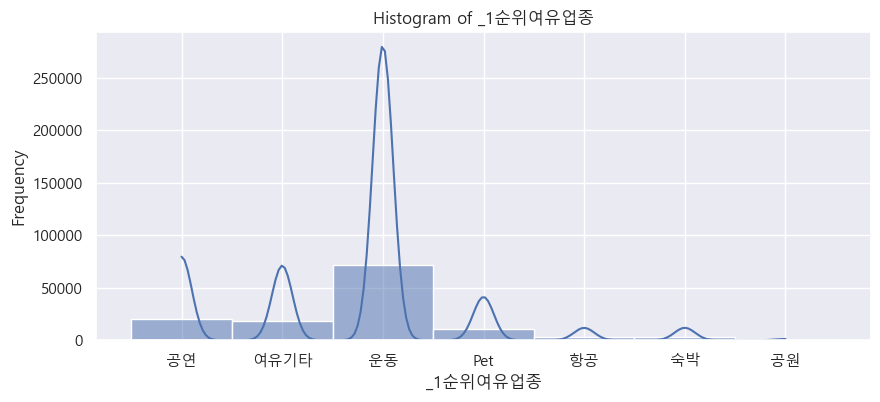


[📦 Boxplot for '_1순위여유업종']



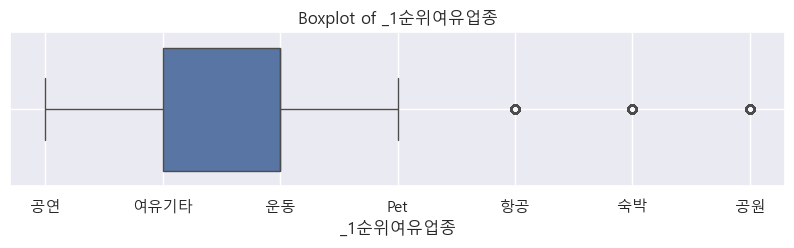

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_1순위여유업종_이용금액']

_1순위여유업종_이용금액
0       372556
210       1279
208       1254
207       1240
209       1236
         ...  
1734         1
1882         1
2519         1
2493         1
2280         1
Name: count, Length: 2615, dtype: int64

[📈 Histogram for '_1순위여유업종_이용금액']



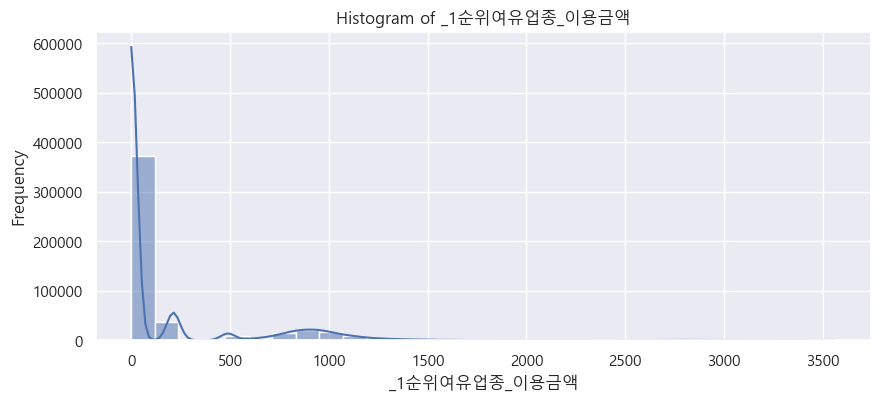


[📦 Boxplot for '_1순위여유업종_이용금액']



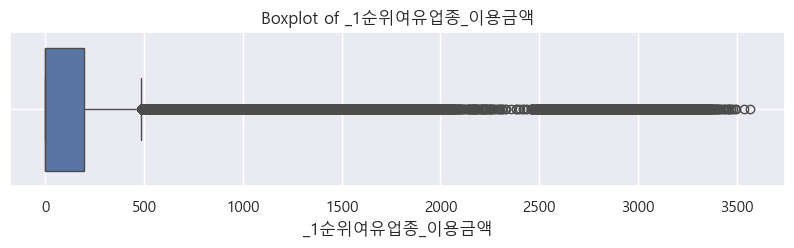

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_2순위여유업종']

_2순위여유업종
None    458787
공연       15421
여유기타     13806
Pet       5959
숙박        4023
운동        1298
공원         706
Name: count, dtype: int64

[📈 Histogram for '_2순위여유업종']



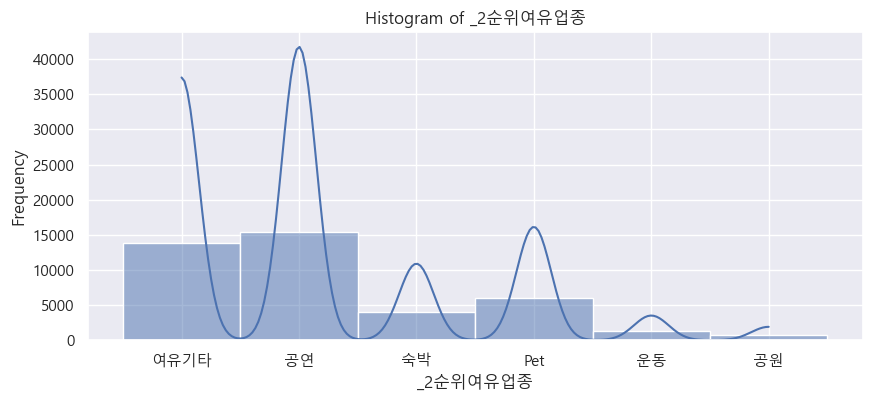


[📦 Boxplot for '_2순위여유업종']



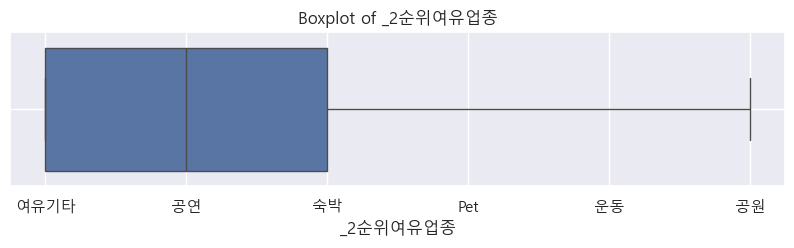

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_2순위여유업종_이용금액']

_2순위여유업종_이용금액
0       458787
208        825
214        795
209        786
207        785
         ...  
2436         1
1387         1
1287         1
1176         1
1996         1
Name: count, Length: 1276, dtype: int64

[📈 Histogram for '_2순위여유업종_이용금액']



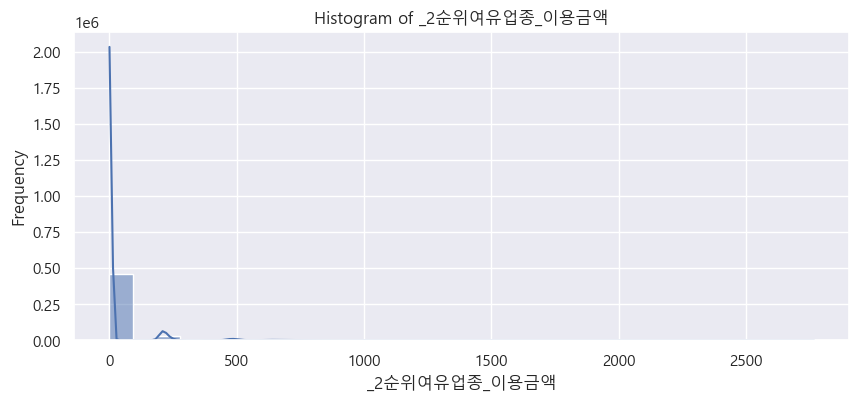


[📦 Boxplot for '_2순위여유업종_이용금액']



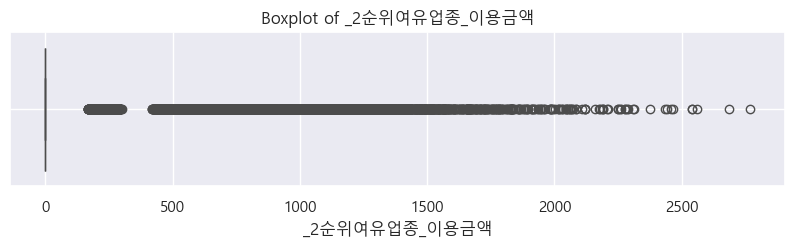

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_3순위여유업종']

_3순위여유업종
None    488455
공연        5730
여유기타      3996
공원         635
숙박         601
Pet        583
Name: count, dtype: int64

[📈 Histogram for '_3순위여유업종']



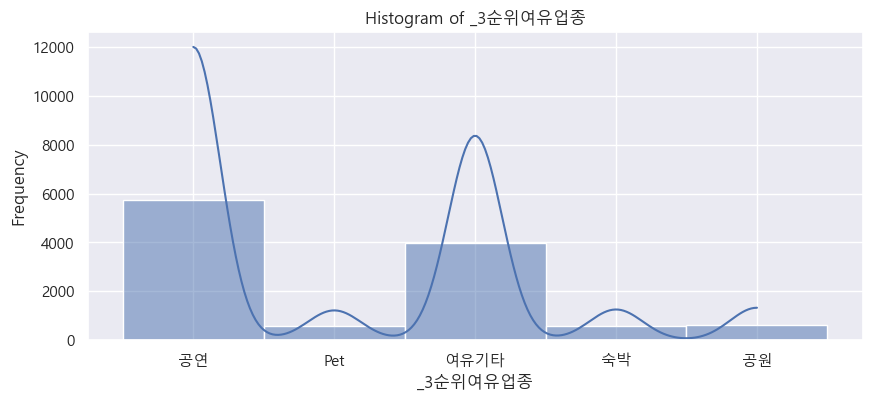


[📦 Boxplot for '_3순위여유업종']



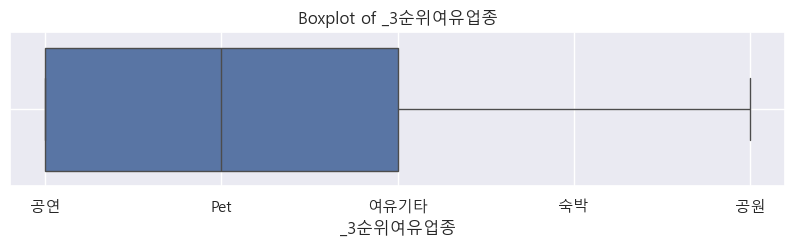

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_3순위여유업종_이용금액']

_3순위여유업종_이용금액
0      488455
210       267
206       263
207       263
204       256
208       250
209       247
205       245
211       243
215       240
203       237
212       235
214       233
217       227
213       226
200       222
216       222
219       221
218       219
220       214
199       205
224       201
202       200
201       200
222    

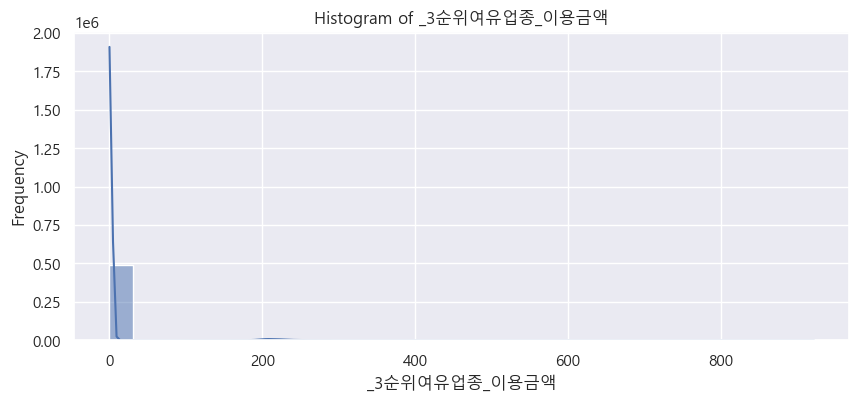


[📦 Boxplot for '_3순위여유업종_이용금액']



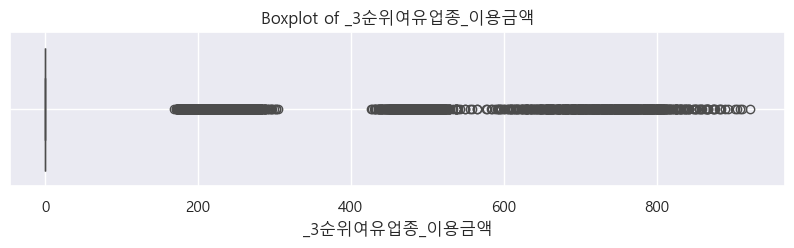

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_1순위납부업종']

_1순위납부업종
None      246185
통신비       126051
납부기타       72832
보험료        38317
관리비        14868
가스/전기료      1747
Name: count, dtype: int64

[📈 Histogram for '_1순위납부업종']



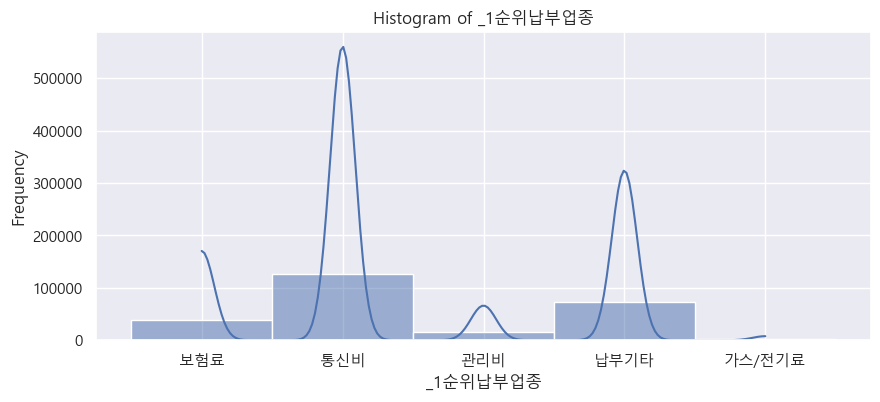


[📦 Boxplot for '_1순위납부업종']



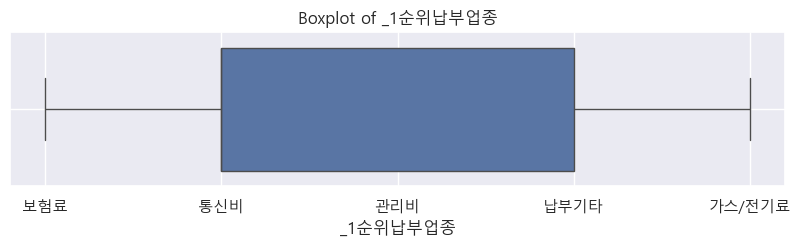

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_1순위납부업종_이용금액']

_1순위납부업종_이용금액
0       246185
24        2092
23        1993
25        1932
22        1697
         ...  
5184         1
5174         1
5209         1
5966         1
5244         1
Name: count, Length: 5663, dtype: int64

[📈 Histogram for '_1순위납부업종_이용금액']



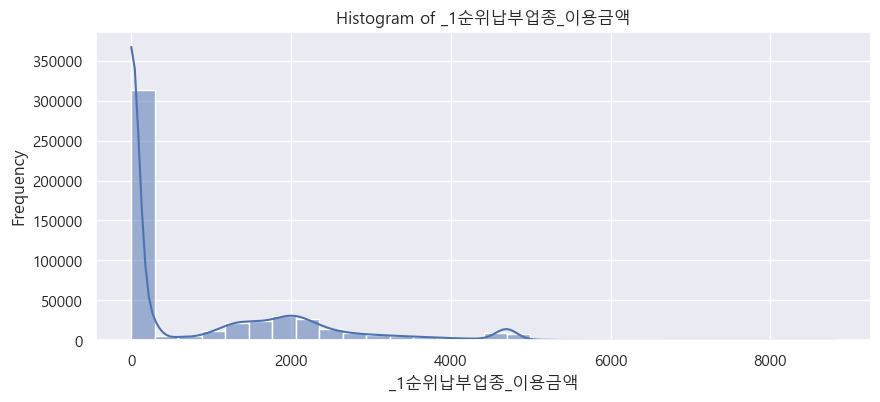


[📦 Boxplot for '_1순위납부업종_이용금액']



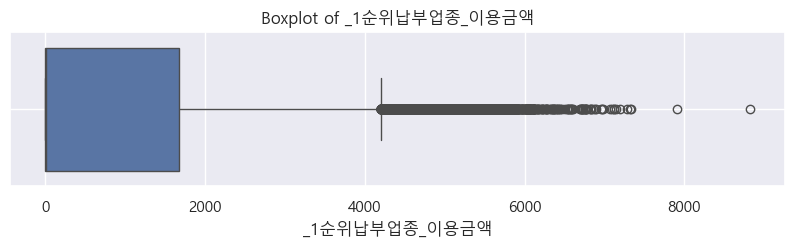

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_2순위납부업종']

_2순위납부업종
None      420641
납부기타       38007
통신비        23228
보험료        13407
가스/전기료      4575
관리비          142
Name: count, dtype: int64

[📈 Histogram for '_2순위납부업종']



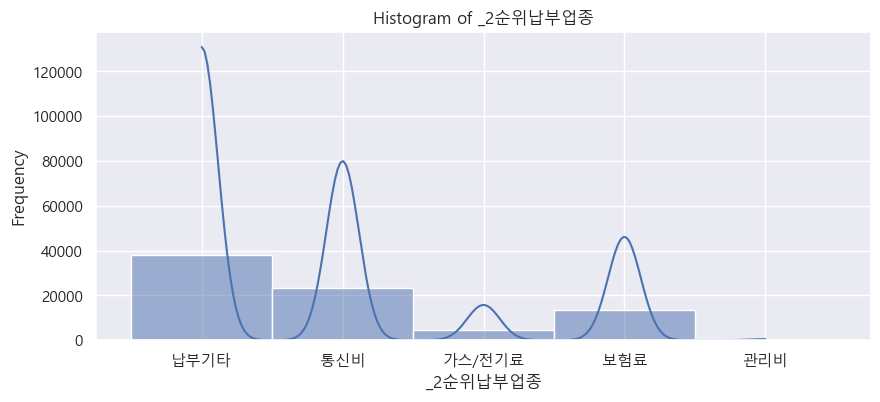


[📦 Boxplot for '_2순위납부업종']



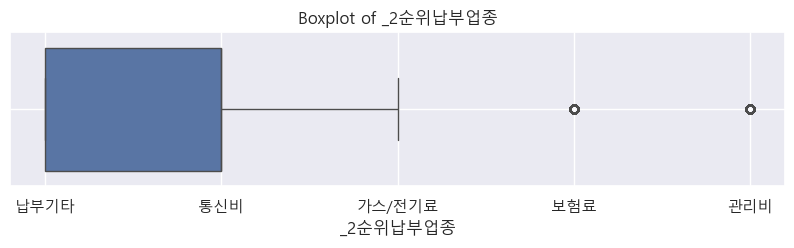

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_2순위납부업종_이용금액']

_2순위납부업종_이용금액
0       420641
51         252
52         251
48         251
49         230
         ...  
4606         1
4559         1
3557         1
4686         1
4456         1
Name: count, Length: 4158, dtype: int64

[📈 Histogram for '_2순위납부업종_이용금액']



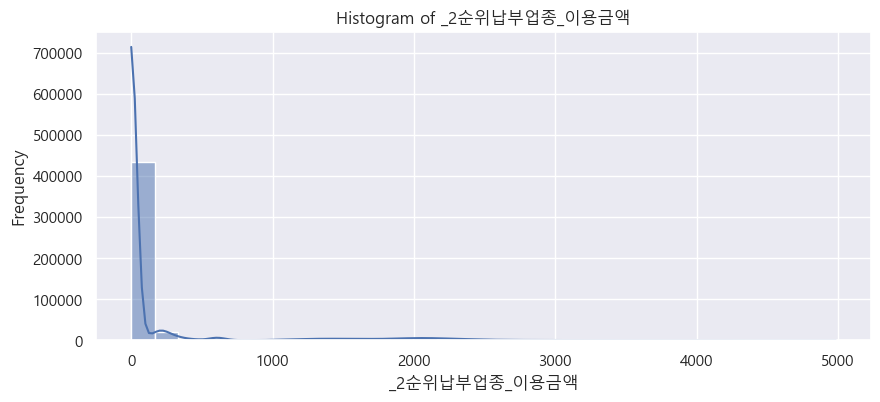


[📦 Boxplot for '_2순위납부업종_이용금액']



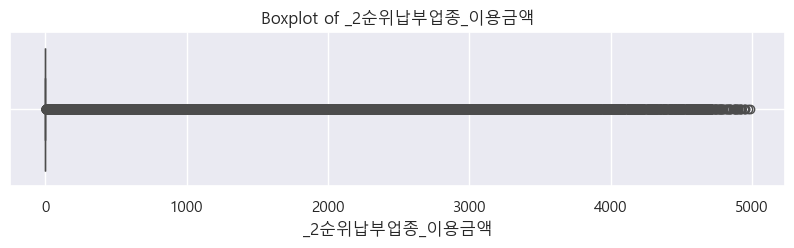

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_3순위납부업종']

_3순위납부업종
None      480780
납부기타       13456
가스/전기료      3068
보험료         1403
통신비         1293
Name: count, dtype: int64

[📈 Histogram for '_3순위납부업종']



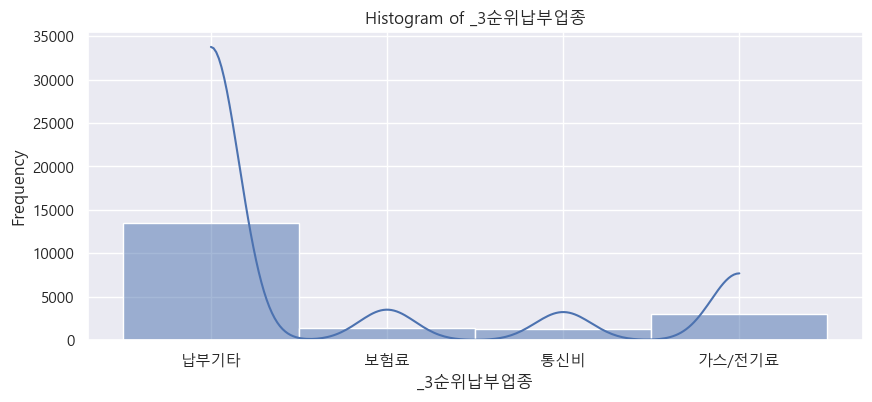


[📦 Boxplot for '_3순위납부업종']



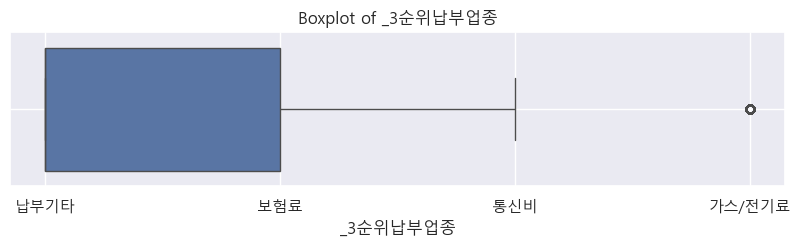

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '_3순위납부업종_이용금액']

_3순위납부업종_이용금액
0       480780
276         67
215         66
243         64
257         64
         ...  
1262         1
2434         1
2253         1
2037         1
1050         1
Name: count, Length: 2052, dtype: int64

[📈 Histogram for '_3순위납부업종_이용금액']



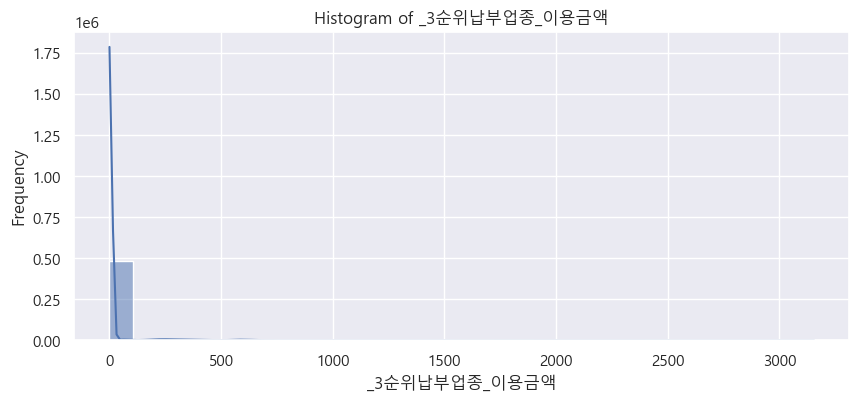


[📦 Boxplot for '_3순위납부업종_이용금액']



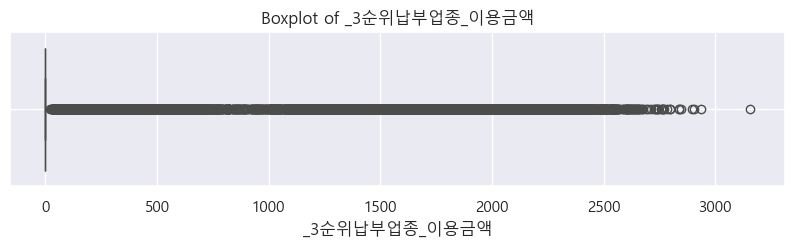

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_3M_R12M']

할부건수_3M_R12M
0     369258
4      37646
3      16533
5      12858
8       8291
6       7075
7       6836
9       6507
10      4916
11      3904
12      3368
13      2840
14      2463
15      2129
16      1859
17      1633
18      1436
19      1313
20      1108
21      1066
22       992
23       857
24       781
25       693
26       624
27       559
28     

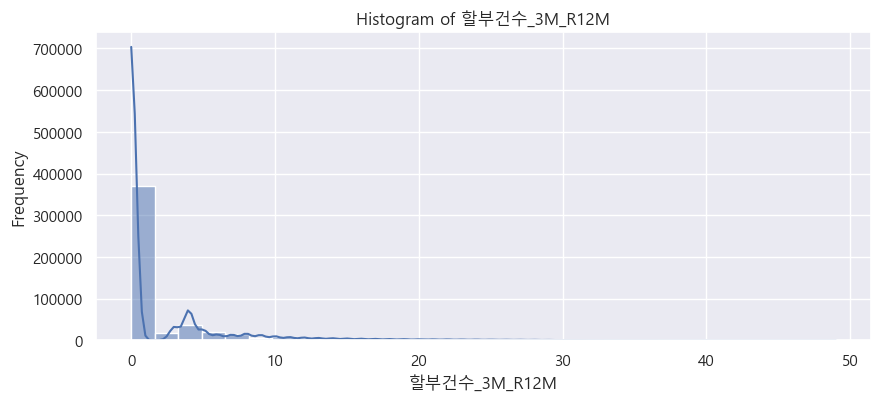


[📦 Boxplot for '할부건수_3M_R12M']



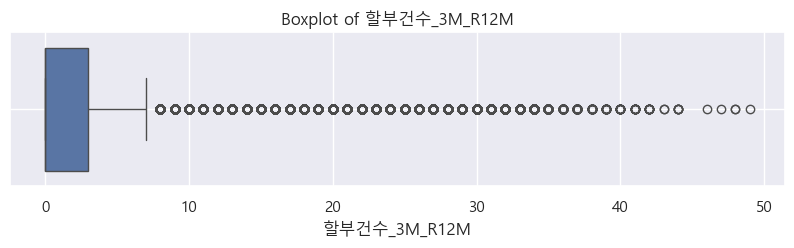

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_6M_R12M']

할부건수_6M_R12M
0     426641
4      32994
3      13957
5       8638
8       3988
6       3941
7       3875
9       2587
10      1490
11       835
12       457
13       314
14       155
15        83
16        29
17        13
19         2
2          1
Name: count, dtype: int64

[📈 Histogram for '할부건수_6M_R12M']



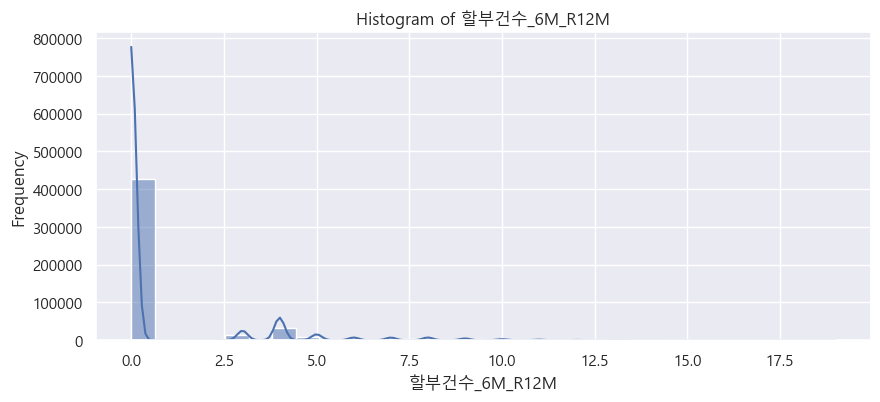


[📦 Boxplot for '할부건수_6M_R12M']



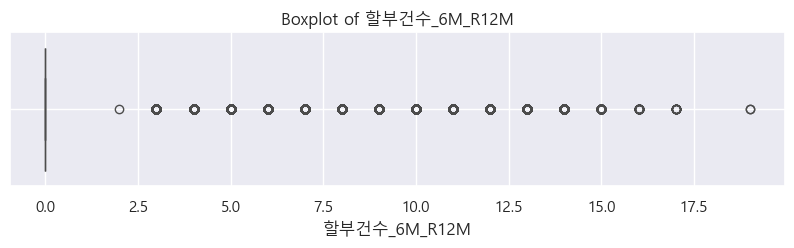

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_12M_R12M']

할부건수_12M_R12M
0     492640
3       5159
4       2013
7        162
6         18
10         8
Name: count, dtype: int64

[📈 Histogram for '할부건수_12M_R12M']



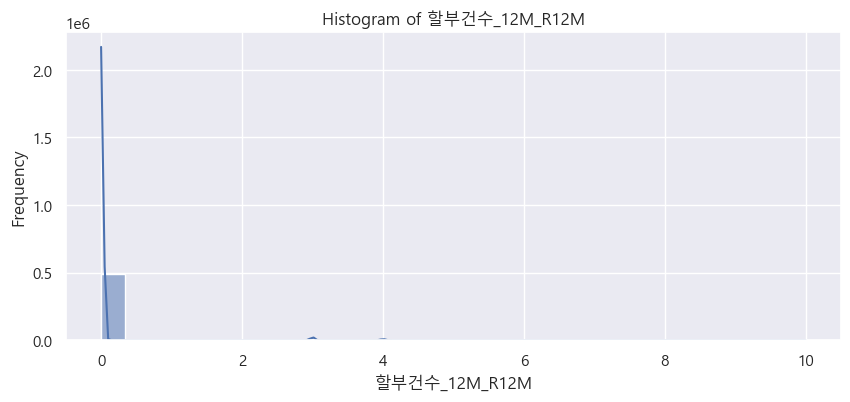


[📦 Boxplot for '할부건수_12M_R12M']



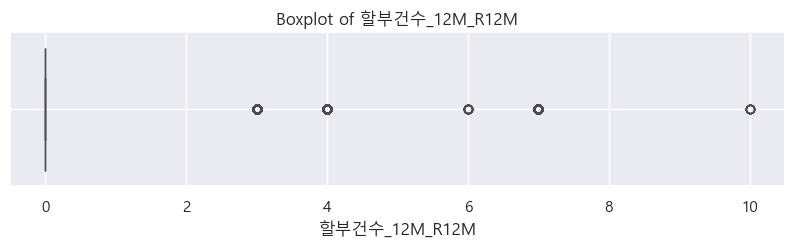

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_14M_R12M']

할부건수_14M_R12M
0    499947
3        50
2         2
4         1
Name: count, dtype: int64

[📈 Histogram for '할부건수_14M_R12M']



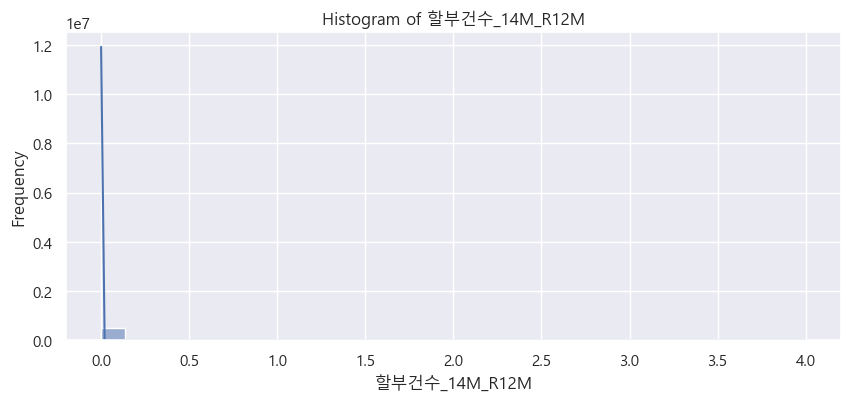


[📦 Boxplot for '할부건수_14M_R12M']



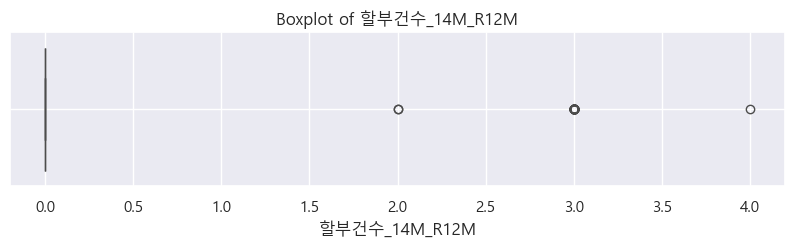

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_3M_R12M']

할부금액_3M_R12M
0        315833
1899         42
2045         41
2263         40
2056         40
          ...  
34617         1
92192         1
23039         1
38047         1
49606         1
Name: count, Length: 36870, dtype: int64

[📈 Histogram for '할부금액_3M_R12M']



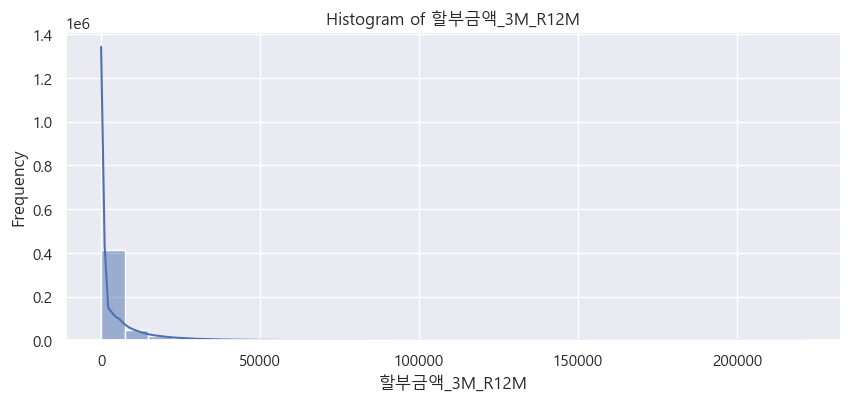


[📦 Boxplot for '할부금액_3M_R12M']



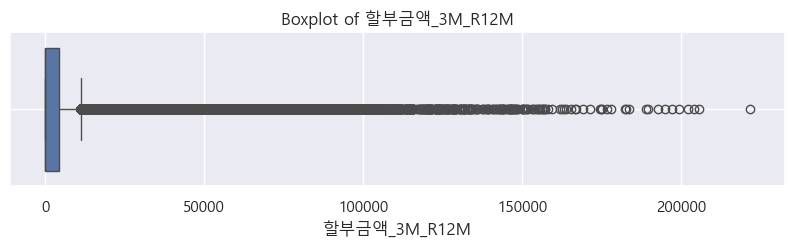

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_6M_R12M']

할부금액_6M_R12M
0        370284
4205         34
6299         32
4271         31
4394         31
          ...  
19981         1
27633         1
18412         1
24350         1
30324         1
Name: count, Length: 22653, dtype: int64

[📈 Histogram for '할부금액_6M_R12M']



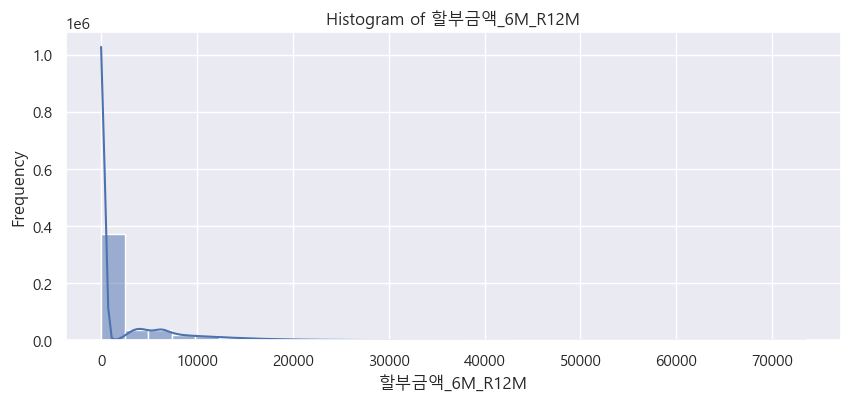


[📦 Boxplot for '할부금액_6M_R12M']



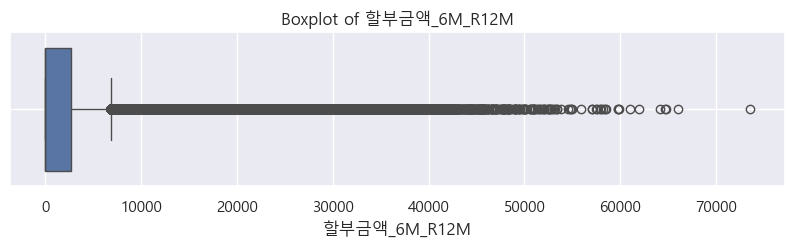

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_12M_R12M']

할부금액_12M_R12M
0        461837
3604         47
3654         46
3462         46
3597         46
          ...  
20625         1
8742          1
9316          1
18038         1
17138         1
Name: count, Length: 8783, dtype: int64

[📈 Histogram for '할부금액_12M_R12M']



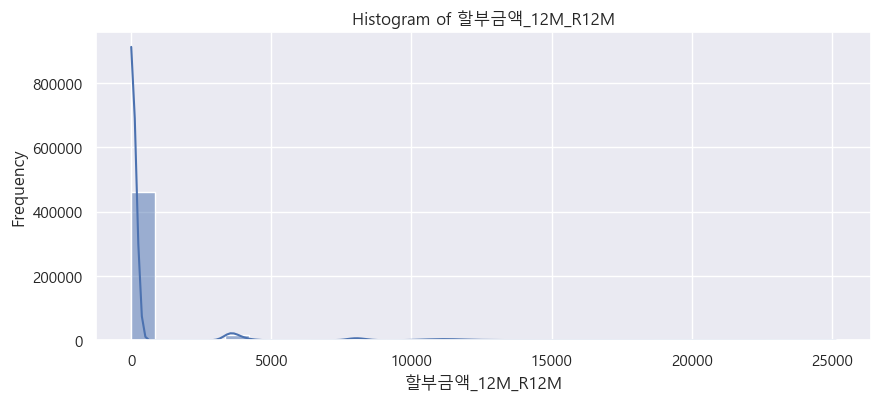


[📦 Boxplot for '할부금액_12M_R12M']



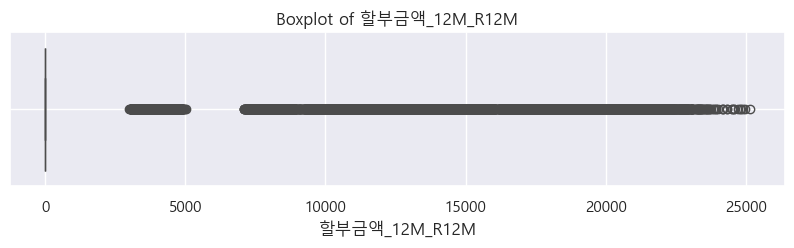

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_14M_R12M']

할부금액_14M_R12M
0        478126
3568        586
3567        579
3569        508
3570        375
          ...  
31342         1
4705          1
9860          1
4789          1
31119         1
Name: count, Length: 1852, dtype: int64

[📈 Histogram for '할부금액_14M_R12M']



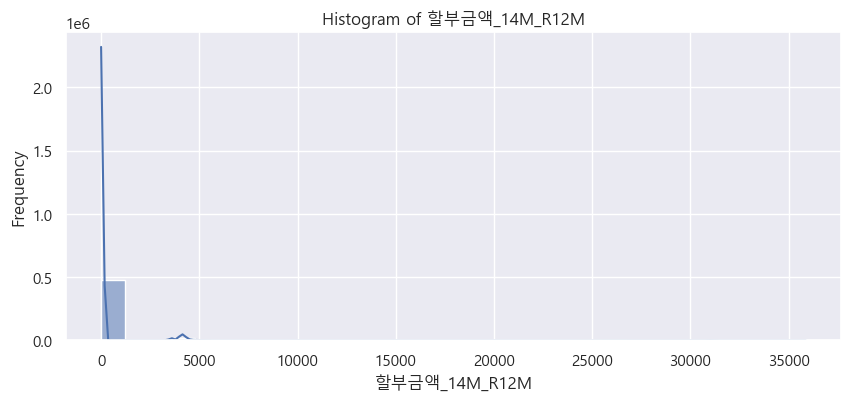


[📦 Boxplot for '할부금액_14M_R12M']



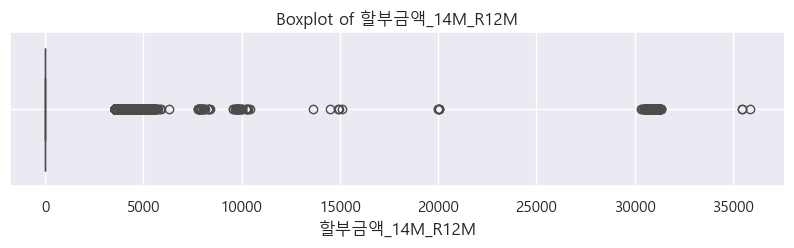

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_유이자_3M_R12M']

할부건수_유이자_3M_R12M
0     459169
4      18770
5       6185
3       6035
6       3084
7       2269
8       1818
9       1322
10       771
11       364
12       131
13        54
14        12
15         9
16         6
17         1
Name: count, dtype: int64

[📈 Histogram for '할부건수_유이자_3M_R12M']



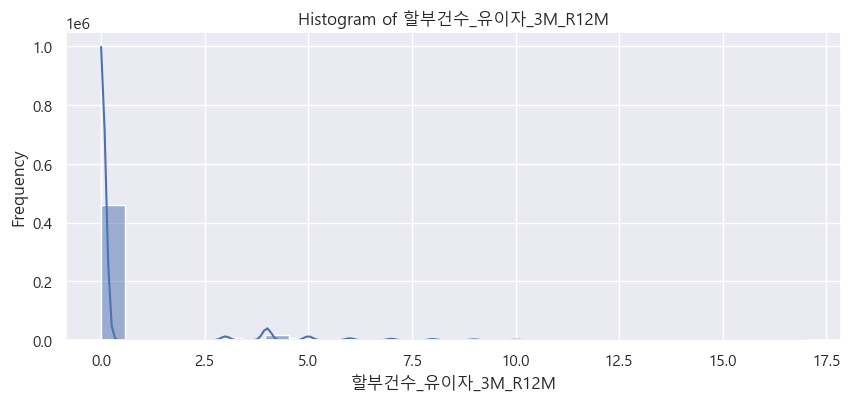


[📦 Boxplot for '할부건수_유이자_3M_R12M']



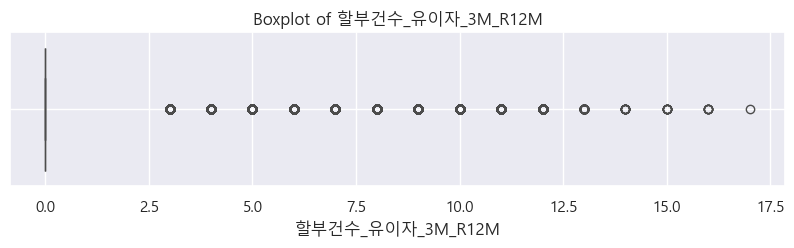

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_유이자_6M_R12M']

할부건수_유이자_6M_R12M
0    488076
4      7334
3      4277
5       313
Name: count, dtype: int64

[📈 Histogram for '할부건수_유이자_6M_R12M']



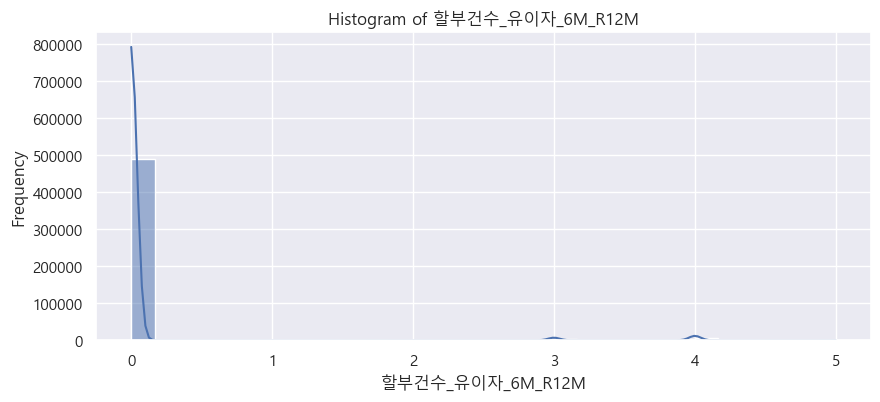


[📦 Boxplot for '할부건수_유이자_6M_R12M']



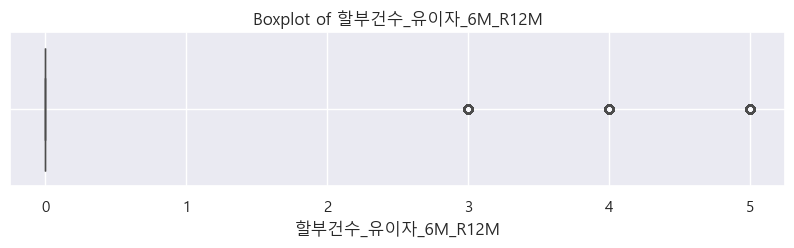

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_유이자_12M_R12M']

할부건수_유이자_12M_R12M
0    497593
4      2183
3       224
Name: count, dtype: int64

[📈 Histogram for '할부건수_유이자_12M_R12M']



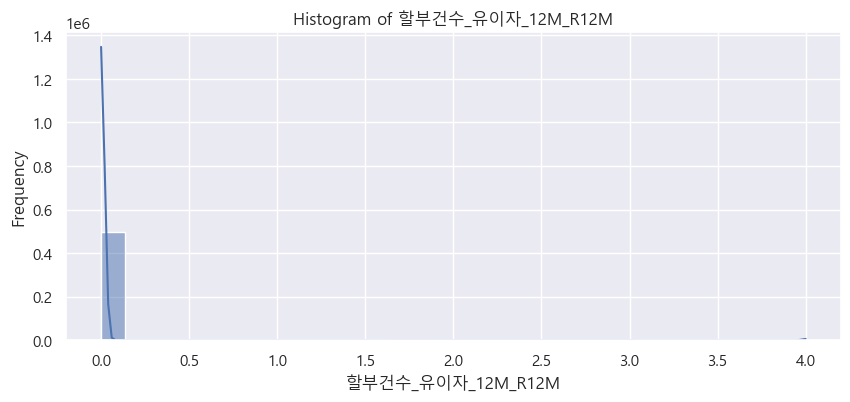


[📦 Boxplot for '할부건수_유이자_12M_R12M']



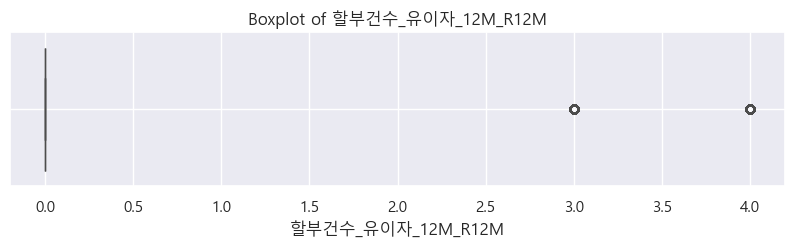

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_유이자_14M_R12M']

할부건수_유이자_14M_R12M
0    499949
3        50
4         1
Name: count, dtype: int64

[📈 Histogram for '할부건수_유이자_14M_R12M']



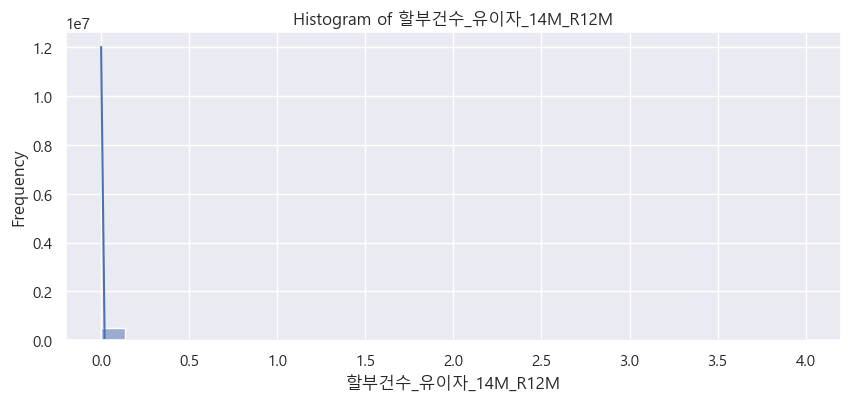


[📦 Boxplot for '할부건수_유이자_14M_R12M']



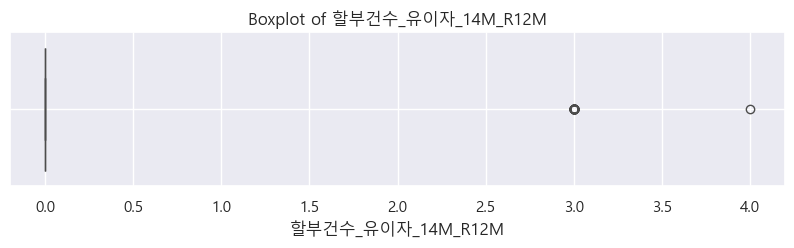

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_유이자_3M_R12M']

할부금액_유이자_3M_R12M
0        433954
5306         27
5111         27
5733         24
4900         24
          ...  
16449         1
16030         1
10728         1
17785         1
12609         1
Name: count, Length: 15242, dtype: int64

[📈 Histogram for '할부금액_유이자_3M_R12M']



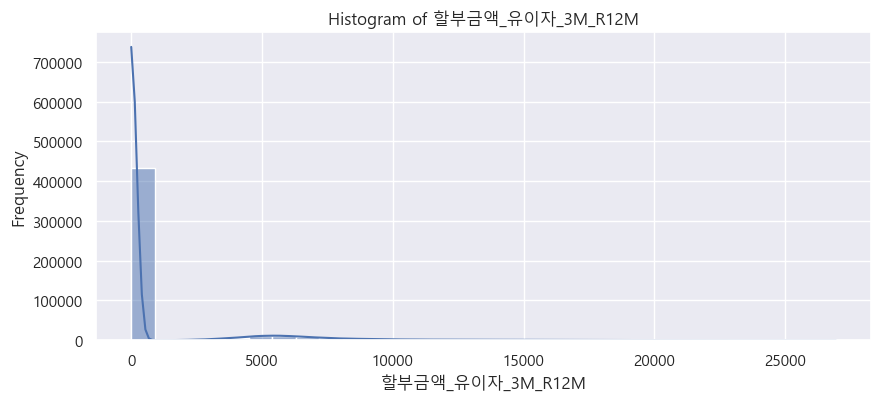


[📦 Boxplot for '할부금액_유이자_3M_R12M']



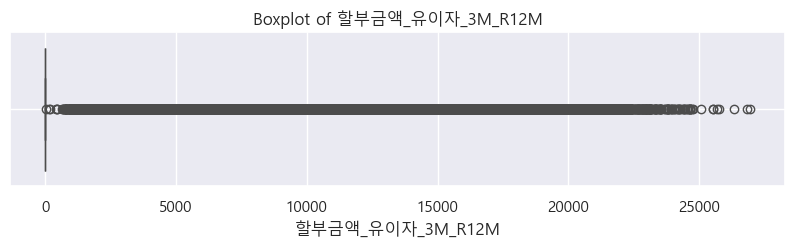

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_유이자_6M_R12M']

할부금액_유이자_6M_R12M
0        468055
6237         25
6484         25
6380         25
6223         24
          ...  
7833          1
10115         1
11663         1
9841          1
8713          1
Name: count, Length: 5646, dtype: int64

[📈 Histogram for '할부금액_유이자_6M_R12M']



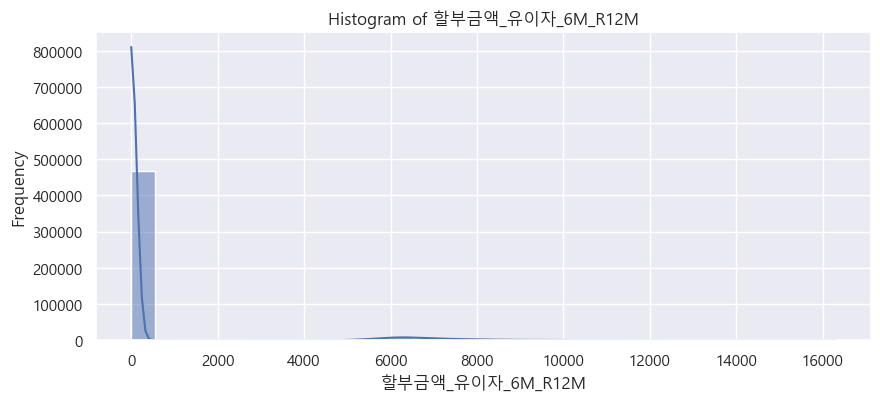


[📦 Boxplot for '할부금액_유이자_6M_R12M']



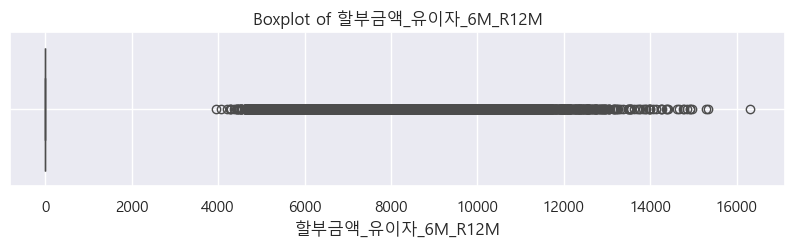

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_유이자_12M_R12M']

할부금액_유이자_12M_R12M
0        489005
10955        13
10835        12
11132        12
11040        12
          ...  
11048         1
13024         1
13505         1
13218         1
13214         1
Name: count, Length: 3785, dtype: int64

[📈 Histogram for '할부금액_유이자_12M_R12M']



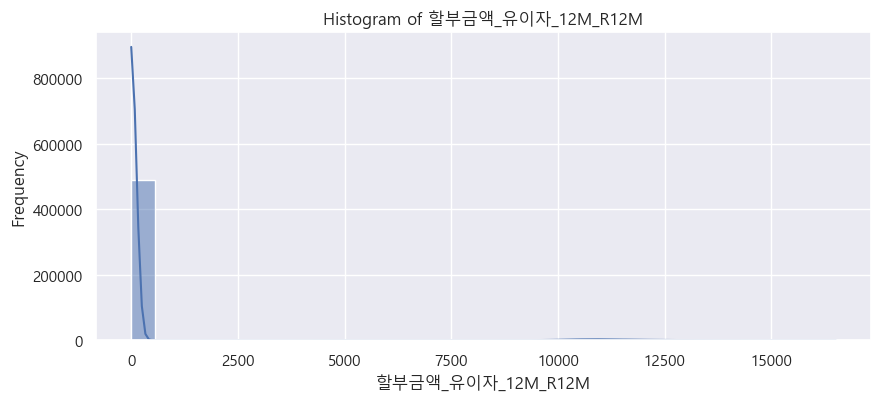


[📦 Boxplot for '할부금액_유이자_12M_R12M']



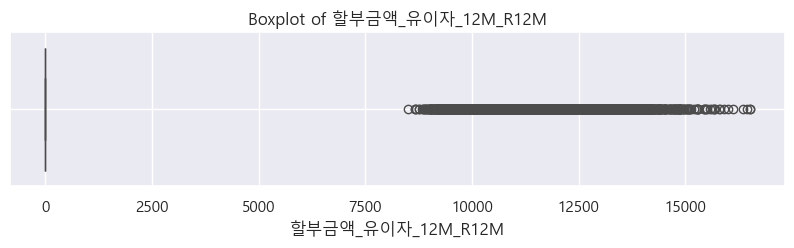

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_유이자_14M_R12M']

할부금액_유이자_14M_R12M
0       482160
4160        63
4108        63
4091        61
4088        61
         ...  
5327         1
4646         1
5200         1
5236         1
5210         1
Name: count, Length: 1372, dtype: int64

[📈 Histogram for '할부금액_유이자_14M_R12M']



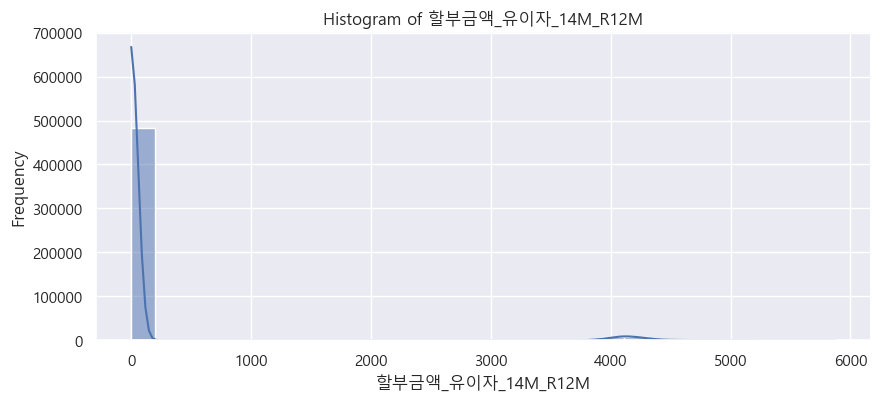


[📦 Boxplot for '할부금액_유이자_14M_R12M']



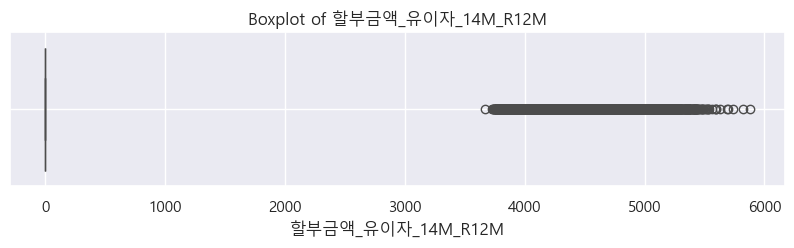

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_무이자_3M_R12M']

할부건수_무이자_3M_R12M
0     377880
4      39652
5      16713
3      16264
6       9552
7       6922
8       5582
9       4250
10      3429
11      2658
12      2129
13      1796
14      1535
15      1309
16      1223
17      1124
18      1010
19       969
20       835
21       777
22       752
23       628
24       531
25       487
26       421
27       300

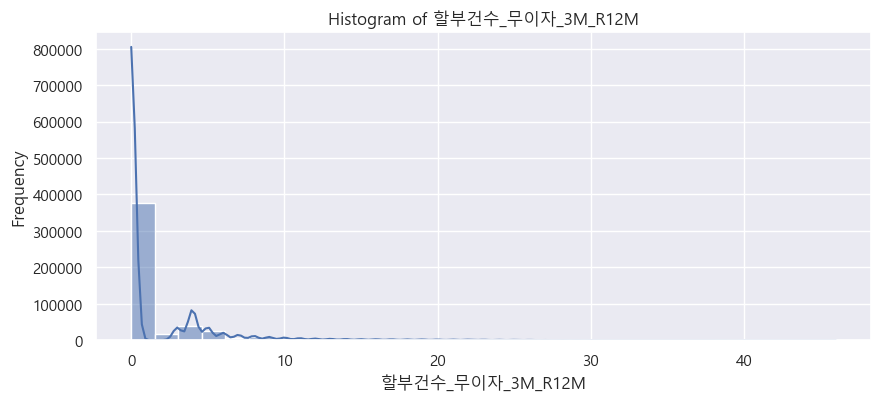


[📦 Boxplot for '할부건수_무이자_3M_R12M']



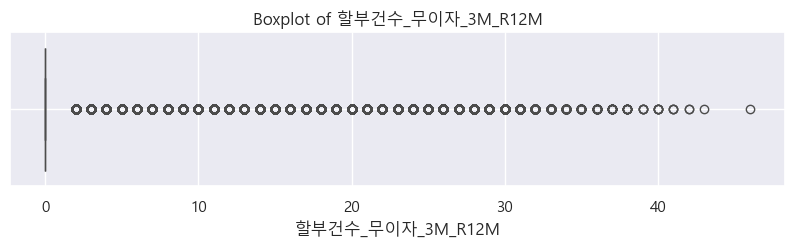

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_무이자_6M_R12M']

할부건수_무이자_6M_R12M
0     431682
4      32830
3      12212
5       9945
6       4541
7       3257
8       2479
9       1667
10       916
11       341
12       101
13        24
14         4
2          1
Name: count, dtype: int64

[📈 Histogram for '할부건수_무이자_6M_R12M']



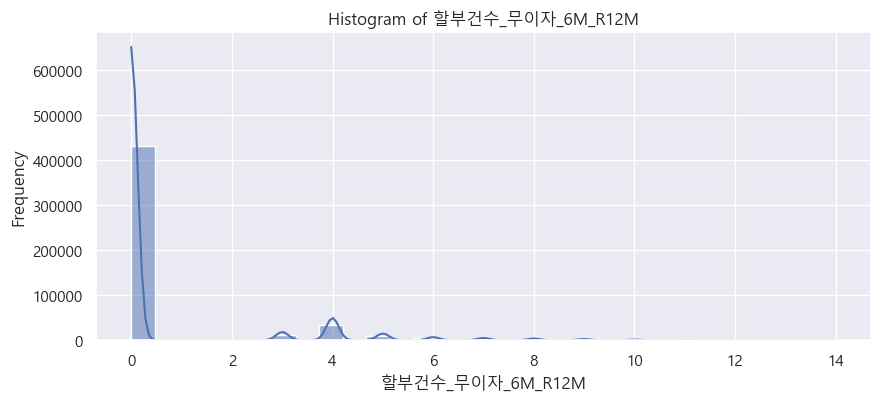


[📦 Boxplot for '할부건수_무이자_6M_R12M']



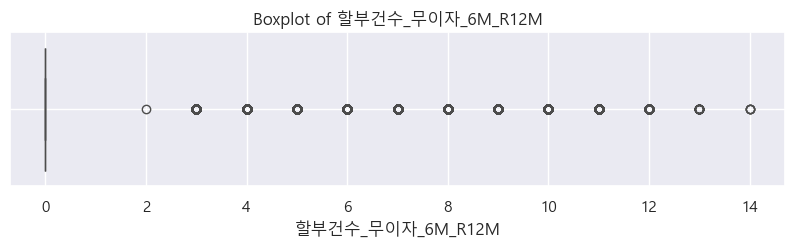

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_무이자_12M_R12M']

할부건수_무이자_12M_R12M
0    494992
3      5008
Name: count, dtype: int64

[📈 Histogram for '할부건수_무이자_12M_R12M']



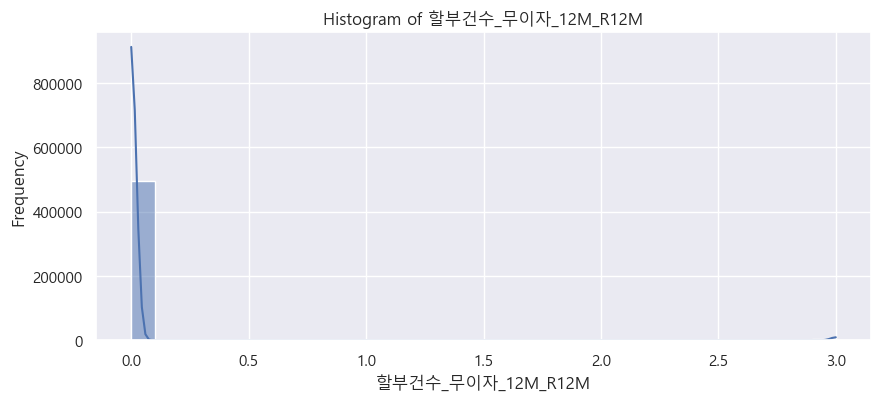


[📦 Boxplot for '할부건수_무이자_12M_R12M']



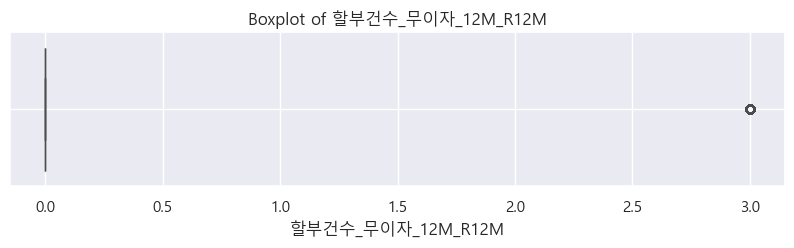

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_무이자_14M_R12M']

할부건수_무이자_14M_R12M
0    499998
2         2
Name: count, dtype: int64

[📈 Histogram for '할부건수_무이자_14M_R12M']



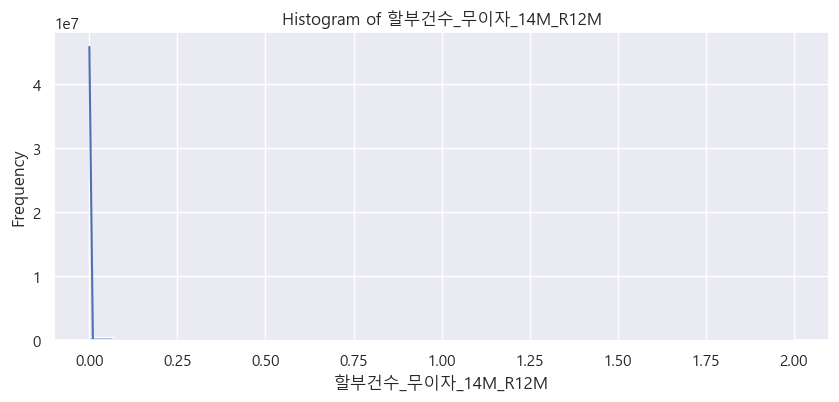


[📦 Boxplot for '할부건수_무이자_14M_R12M']



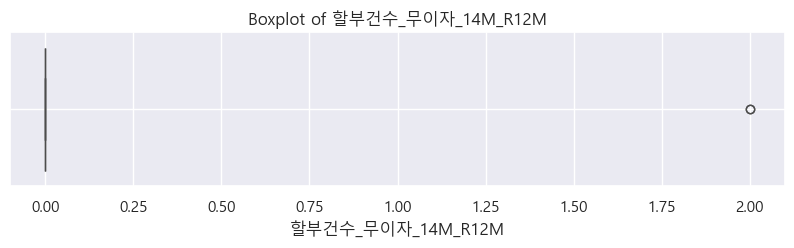

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_무이자_3M_R12M']

할부금액_무이자_3M_R12M
0        328106
2428         51
1899         48
2176         46
1910         46
          ...  
61875         1
39426         1
24853         1
25264         1
90777         1
Name: count, Length: 31550, dtype: int64

[📈 Histogram for '할부금액_무이자_3M_R12M']



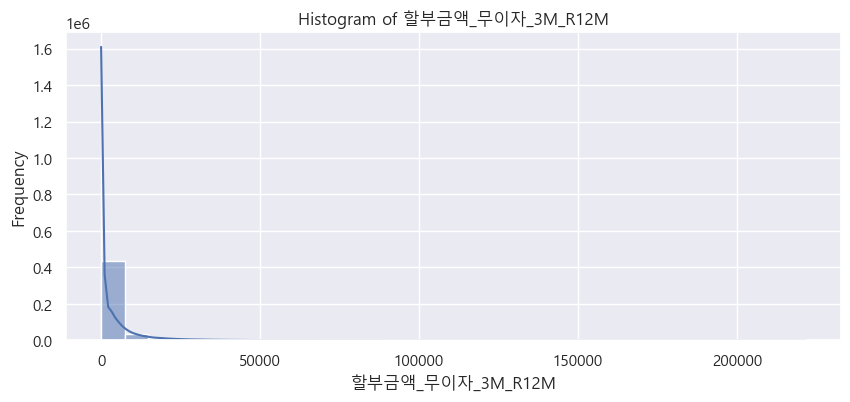


[📦 Boxplot for '할부금액_무이자_3M_R12M']



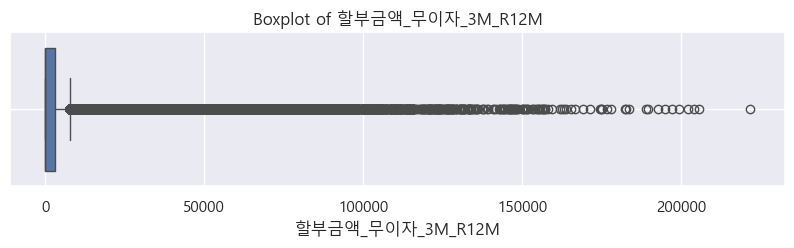

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_무이자_6M_R12M']

할부금액_무이자_6M_R12M
0        381378
4205         35
3856         33
4297         32
4579         32
          ...  
14530         1
12525         1
27518         1
12377         1
30324         1
Name: count, Length: 19775, dtype: int64

[📈 Histogram for '할부금액_무이자_6M_R12M']



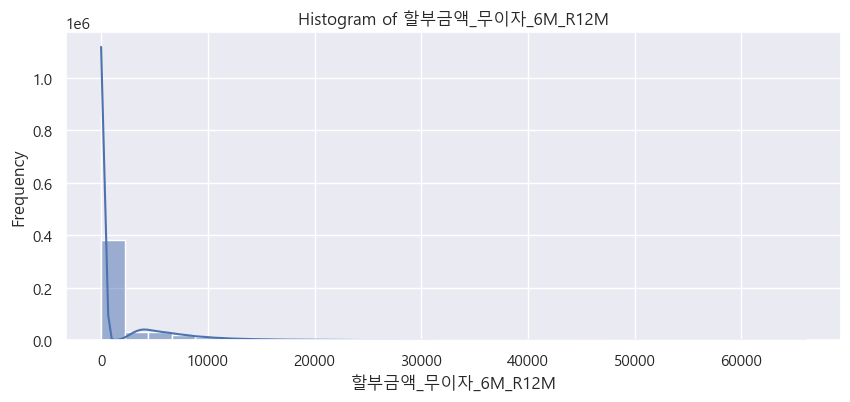


[📦 Boxplot for '할부금액_무이자_6M_R12M']



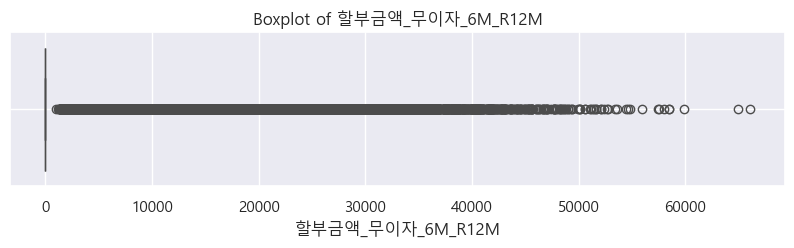

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_무이자_12M_R12M']

할부금액_무이자_12M_R12M
0       477415
3462        53
3497        51
3654        50
3597        49
         ...  
4538         1
4549         1
4433         1
3068         1
4765         1
Name: count, Length: 1533, dtype: int64

[📈 Histogram for '할부금액_무이자_12M_R12M']



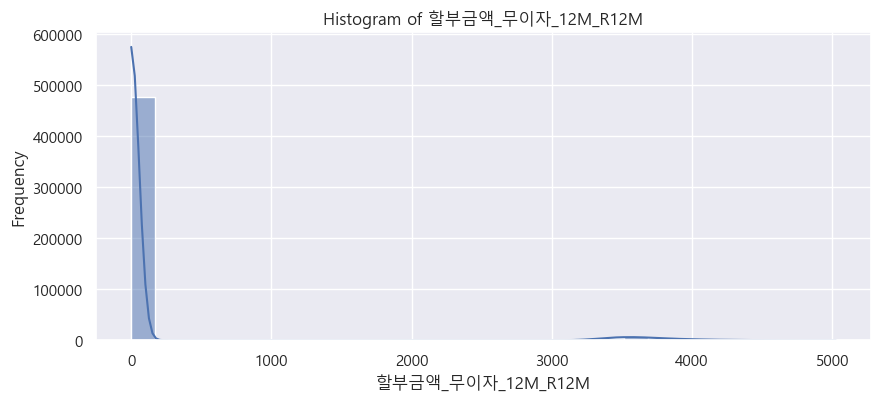


[📦 Boxplot for '할부금액_무이자_12M_R12M']



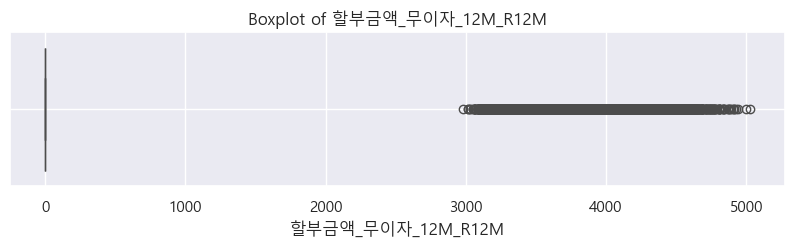

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_무이자_14M_R12M']

할부금액_무이자_14M_R12M
0        495969
3568        586
3567        584
3569        509
3570        378
3566        375
3565        251
3571        223
3572        137
3564        124
3563         71
3573         67
3574         33
3575         29
3562         25
3576         13
3561          9
30880         7
30911         5
31018         5
31154         4

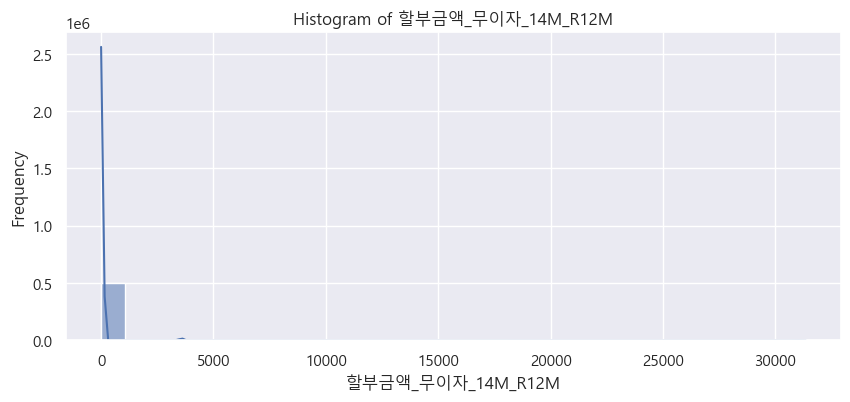


[📦 Boxplot for '할부금액_무이자_14M_R12M']



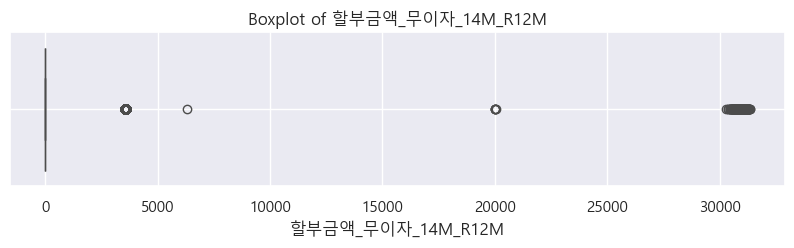

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_부분_3M_R12M']

할부건수_부분_3M_R12M
0    500000
Name: count, dtype: int64

[📈 Histogram for '할부건수_부분_3M_R12M']



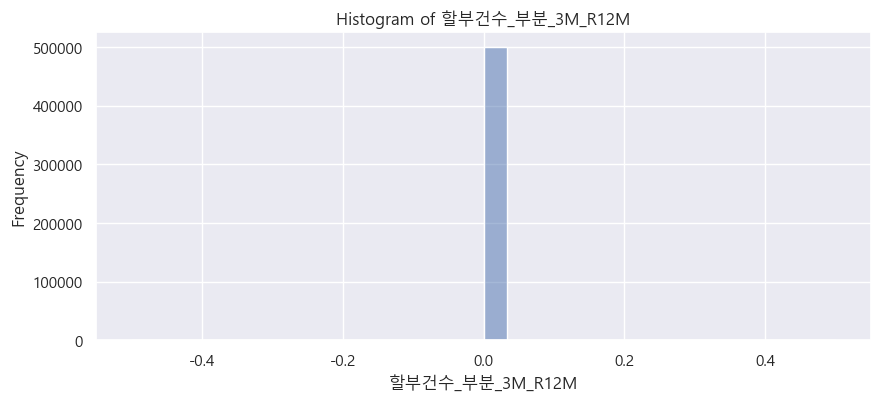


[📦 Boxplot for '할부건수_부분_3M_R12M']



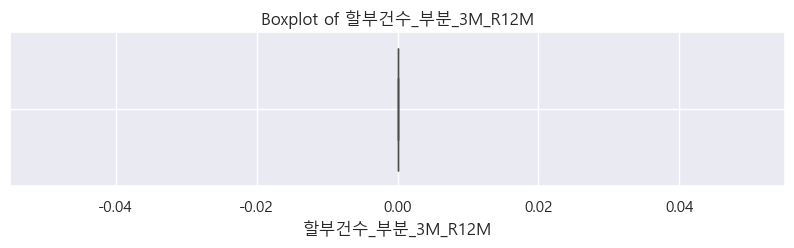

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_부분_6M_R12M']

할부건수_부분_6M_R12M
0    500000
Name: count, dtype: int64

[📈 Histogram for '할부건수_부분_6M_R12M']



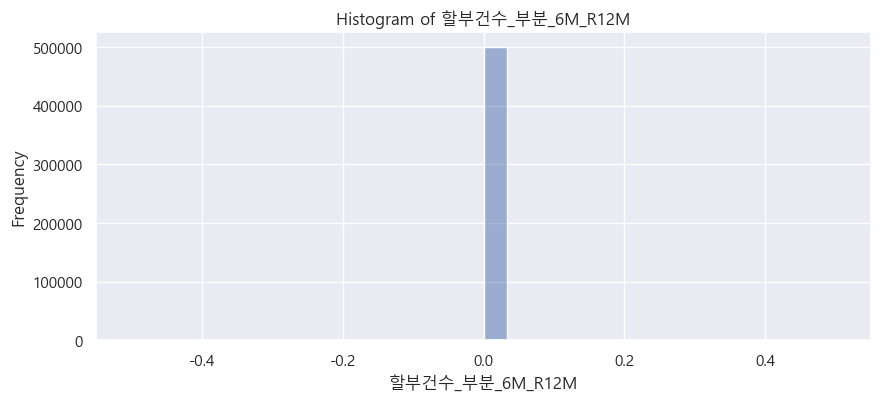


[📦 Boxplot for '할부건수_부분_6M_R12M']



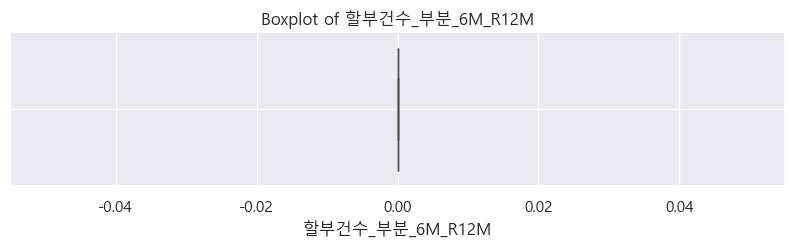

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_부분_12M_R12M']

할부건수_부분_12M_R12M
0    499859
3       141
Name: count, dtype: int64

[📈 Histogram for '할부건수_부분_12M_R12M']



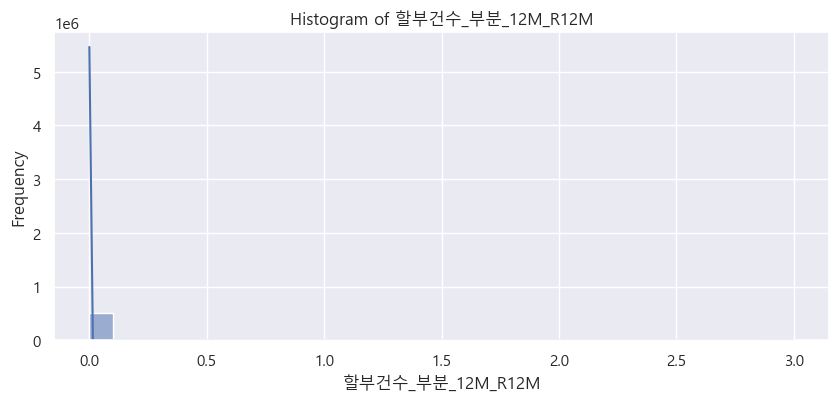


[📦 Boxplot for '할부건수_부분_12M_R12M']



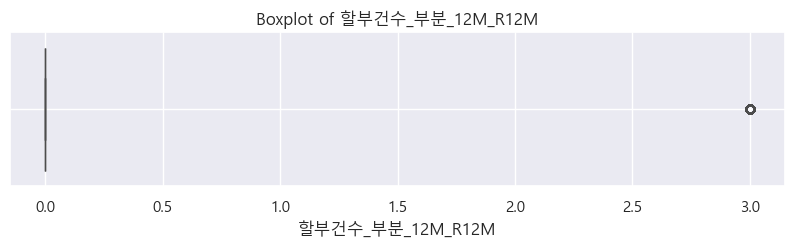

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부건수_부분_14M_R12M']

할부건수_부분_14M_R12M
0    500000
Name: count, dtype: int64

[📈 Histogram for '할부건수_부분_14M_R12M']



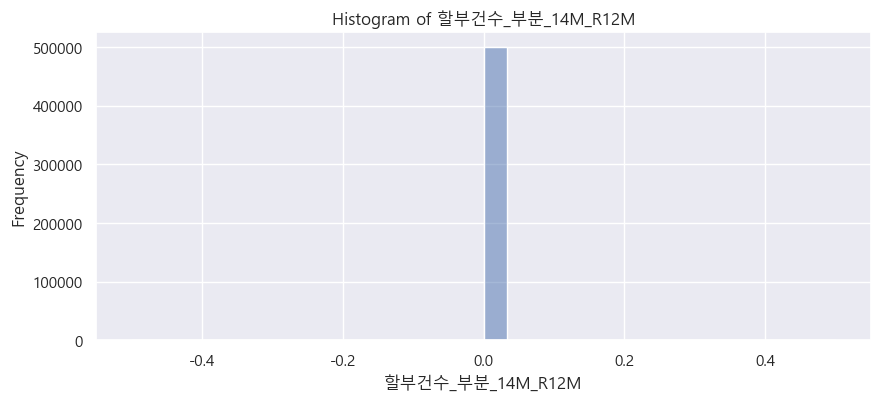


[📦 Boxplot for '할부건수_부분_14M_R12M']



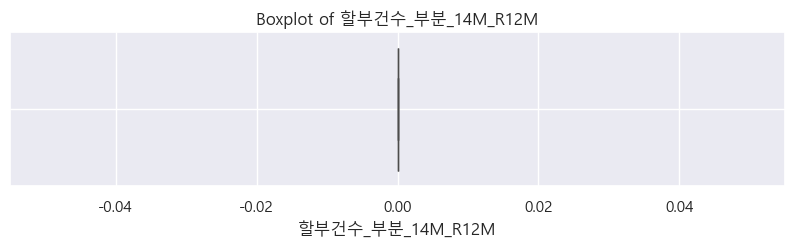

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_부분_3M_R12M']

할부금액_부분_3M_R12M
0    500000
Name: count, dtype: int64

[📈 Histogram for '할부금액_부분_3M_R12M']



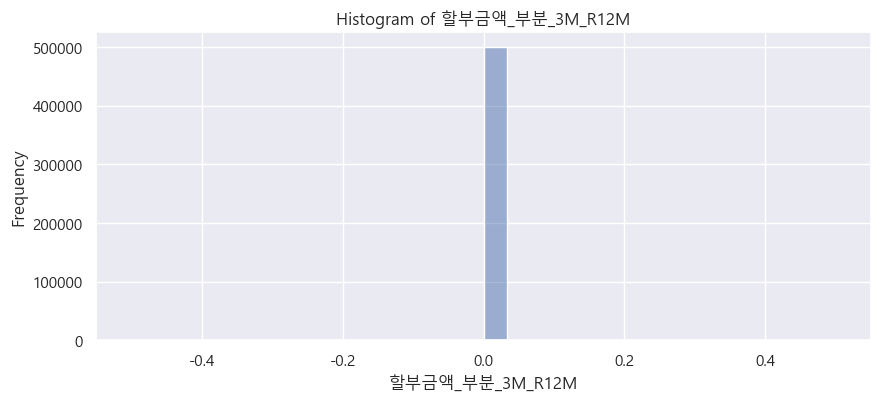


[📦 Boxplot for '할부금액_부분_3M_R12M']



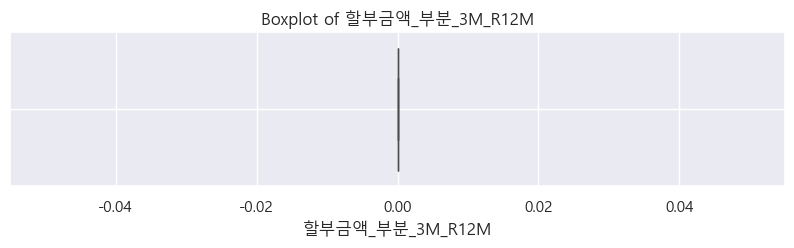

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_부분_6M_R12M']

할부금액_부분_6M_R12M
0    500000
Name: count, dtype: int64

[📈 Histogram for '할부금액_부분_6M_R12M']



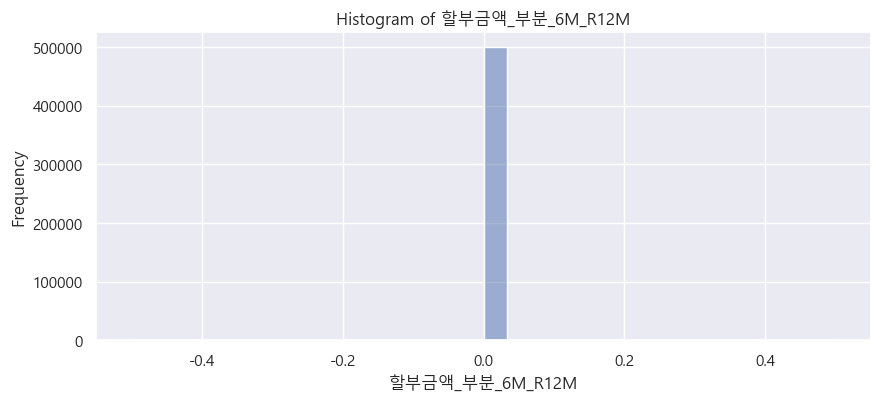


[📦 Boxplot for '할부금액_부분_6M_R12M']



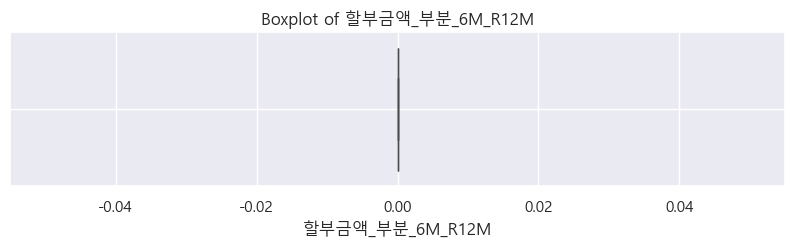

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_부분_12M_R12M']

할부금액_부분_12M_R12M
0       490529
8133        26
7909        21
7944        20
8037        20
         ...  
7519         1
7553         1
8712         1
8904         1
7176         1
Name: count, Length: 1678, dtype: int64

[📈 Histogram for '할부금액_부분_12M_R12M']



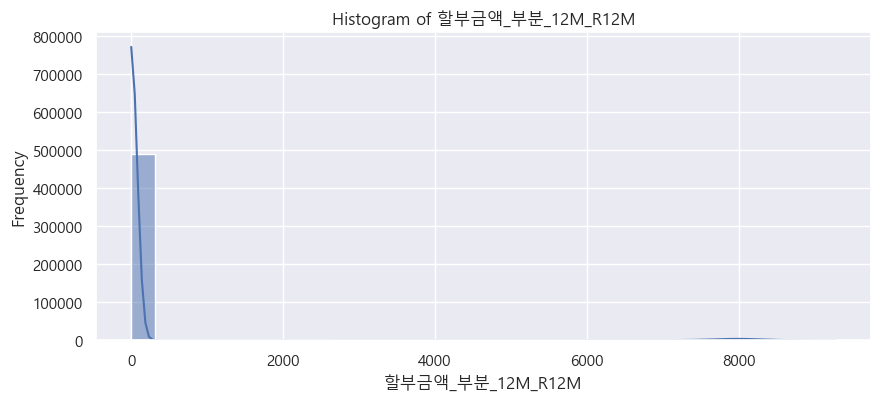


[📦 Boxplot for '할부금액_부분_12M_R12M']



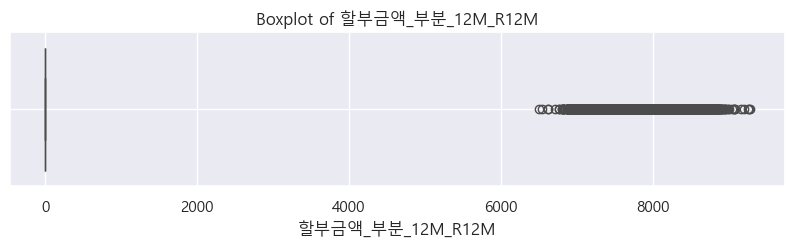

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------

[📊 Value Counts for '할부금액_부분_14M_R12M']

할부금액_부분_14M_R12M
0        499967
10266         1
9920          1
9553          1
10298         1
9806          1
9987          1
9727          1
9770          1
10065         1
9772          1
10195         1
9670          1
9747          1
9826          1
10196         1
9706          1
9582          1
10115         1
10037         1
9860          1
9

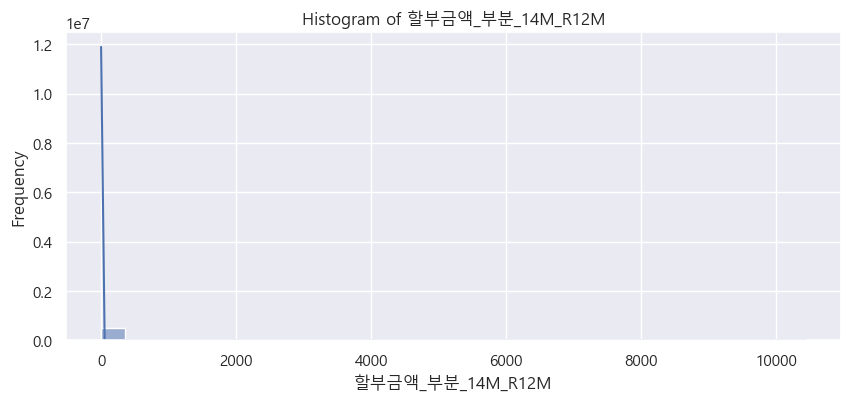


[📦 Boxplot for '할부금액_부분_14M_R12M']



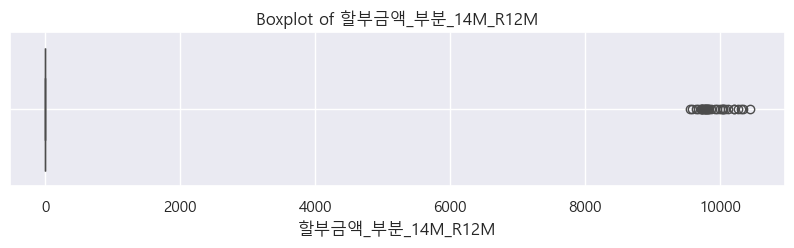

------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------------------------------------


In [49]:
# 컬럼 하나하나 반복해서 출력하게 해준다.
for a1 in column_list:
    analyze_column(f"{a1}")
    print('-' * 150)
    print('-' * 150)
    print('-' * 150)
    print('-' * 150)

0만 존재 : 여유_여행이용금액, 납부_렌탈료이용금액, 납부_건강연금이용금액, 할부건수_부분_6M_R12M, 할부건수_부분_14M_R12M, 할부금액_부분_3M_R12M, 할부금액_부분_6M_R12M

결측치: None에는 기타를 채워넣어야하는가?
인코딩: 할부건수_12M_R12M, 할부건수_14M_R12M, 할부건수_유이자_6M_R12M, 할부건수_유이자_12M_R12M, 할부건수_유이자_14M_R12M, 할부건수_부분_12M_R12M
할부건수_무이자_12M_R12M, 할부건수_무이자_14M_R12M


### 📌 최근 3개월 이용 내역

- `이용가맹점수` : 전체 이용 가맹점 수
- `최근 3개월 이용 가맹점수` : 최근 3개월 동안 이용한 서로 다른 가맹점 수
- `이용금액_해외` : 최근 3개월간 해외에서 결제한 금액

#### 🛍 쇼핑 관련 이용금액
- `쇼핑_도소매_이용금액` : 오프라인 일반 도소매 업종에서의 이용금액
- `최근 3개월 쇼핑 도소매 이용금액` : 최근 3개월간 도소매 업종 전체 이용금액
- `쇼핑_백화점_이용금액` : 백화점에서의 카드 이용금액
- `쇼핑_마트_이용금액` : 대형 마트에서의 카드 이용금액
- `쇼핑_슈퍼마켓_이용금액` : 슈퍼마켓에서의 카드 이용금액
- `쇼핑_편의점_이용금액` : 편의점에서의 카드 이용금액
- `쇼핑_아울렛_이용금액` : 아울렛 매장에서의 카드 이용금액
- `쇼핑_온라인_이용금액` : 온라인 쇼핑몰에서의 카드 이용금액
- `쇼핑_기타_이용금액` : 기타 쇼핑 관련 업종에서의 카드 이용금액

#### 🚗 교통 관련 이용금액
- `교통_주유이용금액` : 주유소에서의 유류비 카드 사용액
- `교통_정비이용금액` : 자동차 정비, 수리 업종에서의 이용금액
- `교통_통행료이용금액` : 고속도로, 유료도로 통행료
- `교통_버스지하철이용금액` : 대중교통(버스/지하철) 이용금액
- `교통_택시이용금액` : 택시 이용 시 결제금액
- `교통_철도버스이용금액` : KTX, 고속버스 등 장거리 교통수단 이용금액

#### 🎈 여유/레저 관련 이용금액
- `여유_운동이용금액` : 헬스장, 스포츠센터 등 운동시설 이용금액
- `여유_Pet이용금액` : 반려동물 관련 지출 (병원, 미용, 사료 등)
- `여유_공연이용금액` : 영화, 콘서트, 뮤지컬 등 공연 관련 지출
- `여유_공원이용금액` : 놀이공원, 테마파크 등 이용금액
- `여유_숙박이용금액` : 호텔, 모텔 등 숙박업소 지출
- `여유_여행이용금액` : 여행사, 여행상품 이용금액
- `여유_항공이용금액` : 항공권 예매 및 항공업종 지출
- `여유_기타이용금액` : 여가/레저 관련 기타 업종 지출

#### 💰 납부 관련 이용금액
- `납부_통신비이용금액` : 휴대폰, 인터넷 등 통신비 지출
- `납부_관리비이용금액` : 아파트/주택 관리비 납부 금액
- `납부_렌탈료이용금액` : 정수기, 공기청정기 등 렌탈 상품 이용료
- `납부_가스전기료이용금액` : 도시가스, 전기요금 등 공과금
- `납부_보험료이용금액` : 생명보험, 자동차보험 등 지출
- `납부_유선방송이용금액` : IPTV, 케이블방송 등 방송요금
- `납부_건강연금이용금액` : 건강보험, 국민연금 등 사회보장성 지출
- `납부_기타이용금액` : 기타 납부성 지출 (예: 세금 등)

---

### 🏆 최근 3개월 업종별 이용 순위

#### 🔹 전체 업종
- `_1순위업종` : 가장 많이 이용한 업종
- `_1순위업종_이용금액` : 1순위 업종에서의 이용금액
- `_2순위업종` : 두 번째로 많이 이용한 업종
- `_2순위업종_이용금액` : 2순위 업종에서의 이용금액
- `_3순위업종` : 세 번째로 많이 이용한 업종
- `_3순위업종_이용금액` : 3순위 업종에서의 이용금액

#### 🔹 쇼핑 업종
- `_1순위쇼핑업종` ~ `_3순위쇼핑업종_이용금액` : 동일한 방식으로 쇼핑 업종 기준 순위 및 금액

#### 🔹 교통 업종
- `_1순위교통업종` ~ `_3순위교통업종_이용금액` : 동일한 방식으로 교통 업종 기준 순위 및 금액

#### 🔹 여유 업종
- `_1순위여유업종` ~ `_3순위여유업종_이용금액` : 동일한 방식으로 여유 업종 기준 순위 및 금액

#### 🔹 납부 업종
- `_1순위납부업종` ~ `_3순위납부업종_이용금액` : 동일한 방식으로 납부 업종 기준 순위 및 금액

---

### 💳 최근 1년 할부 이용 내역

#### 🔹 전체 할부 건수/금액
- `할부건수_3M_R12M` : 최근 1년간 3개월 이하 할부건수
- `할부건수_6M_R12M` : 최근 1년간 4~6개월 할부건수
- `할부건수_12M_R12M` : 최근 1년간 7~12개월 할부건수
- `할부건수_14M_R12M` : 최근 1년간 12개월 초과 할부건수
- `할부금액_3M_R12M` ~ `할부금액_14M_R12M` : 위 구간별 할부 금액

#### 🔹 유이자 할부
- `할부건수_유이자_*` : 해당 구간 유이자 할부건수 (무이자/부분 무이자 제외)
- `할부금액_유이자_*` : 해당 구간 유이자 할부금액

#### 🔹 무이자 할부
- `할부건수_무이자_*` : 해당 구간 무이자 할부건수
- `할부금액_무이자_*` : 해당 구간 무이자 할부금액

#### 🔹 부분 무이자 할부
- `할부건수_부분_*` : 해당 구간 부분 무이자 할부건수
- `할부금액_부분_*` : 해당 구간 부분 무이자 할부금액


In [60]:
all_df.duplicated().sum()

0

In [62]:
all_df[column_list].dtypes

이용가맹점수                int64
이용금액_해외               int64
쇼핑_도소매_이용금액           int64
쇼핑_백화점_이용금액           int64
쇼핑_마트_이용금액            int64
쇼핑_슈퍼마켓_이용금액          int64
쇼핑_편의점_이용금액           int64
쇼핑_아울렛_이용금액           int64
쇼핑_온라인_이용금액           int64
쇼핑_기타_이용금액            int64
교통_주유이용금액             int64
교통_정비이용금액             int64
교통_통행료이용금액            int64
교통_버스지하철이용금액          int64
교통_택시이용금액             int64
교통_철도버스이용금액           int64
여유_운동이용금액             int64
여유_Pet이용금액            int64
여유_공연이용금액             int64
여유_공원이용금액             int64
여유_숙박이용금액             int64
여유_여행이용금액             int64
여유_항공이용금액             int64
여유_기타이용금액             int64
납부_통신비이용금액            int64
납부_관리비이용금액            int64
납부_렌탈료이용금액            int64
납부_가스전기료이용금액          int64
납부_보험료이용금액            int64
납부_유선방송이용금액           int64
납부_건강연금이용금액           int64
납부_기타이용금액             int64
_1순위업종               object
_1순위업종_이용금액           int64
_2순위업종               object
_2순위업종_이용금액         